# I. Data 준비 및 통합

## 1. 데이터 불러오기 및 스키마 표준화

# 제 13회 2025 AI·데이터 경진대회 | 빅데이터 콘테스트  
### AI 데이터분석 분야: 미래를 예측하는 데이터 챌린지  

**“우리 동네 가맹점, 위기 신호를 미리 잡아라!”**


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df1 = pd.read_csv('data/raw/smallbiz-data-raw-1.csv', encoding='cp949')
df2 = pd.read_csv('data/raw/smallbiz-data-raw-2.csv', encoding='cp949')
df3 = pd.read_csv('data/raw/smallbiz-data-raw-3.csv', encoding='cp949')

### 1) 컬럼명 한국어로 변경

In [ ]:
# 매핑 (엑셀 레이아웃 기준)
mapping1 = {
    'ENCODED_MCT': '가맹점구분번호',
    'MCT_BSE_AR': '가맹점주소',
    'MCT_NM': '가맹점명',
    'MCT_BRD_NUM': '브랜드구분코드',
    'MCT_SIGUNGU_NM': '가맹점지역',
    'HPSN_MCT_ZCD_NM': '업종',
    'HPSN_MCT_BZN_CD_NM': '상권',
    'ARE_D': '개설일',
    'MCT_ME_D': '폐업일'
}

mapping2 = {
    'ENCODED_MCT': '가맹점구분번호',
    'TA_YM': '기준년월',
    'MCT_OPE_MS_CN': '가맹점 운영개월수 구간',
    'RC_M1_SAA': '매출금액 구간',
    'RC_M1_TO_UE_CT': '매출건수 구간',
    'RC_M1_UE_CUS_CN': '유니크 고객 수 구간',
    'RC_M1_AV_NP_AT': '객단가 구간',
    'APV_CE_RAT': '취소율 구간',
    'DLV_SAA_RAT': '배달매출금액 비율',
    'M1_SME_RY_SAA_RAT': '동일 업종 매출금액 비율',
    'M1_SME_RY_CNT_RAT': '동일 업종 매출건수 비율',
    'M12_SME_RY_SAA_PCE_RT': '동일 업종 내 매출 순위 비율',
    'M12_SME_BZN_SAA_PCE_RT': '동일 상권 내 매출 순위 비율',
    'M12_SME_RY_ME_MCT_RAT': '동일 업종 내 해지 가맹점 비중',
    'M12_SME_BZN_ME_MCT_RAT': '동일 상권 내 해지 가맹점 비중'
}

mapping3 = {
    'ENCODED_MCT': '가맹점구분번호',
    'TA_YM': '기준년월',
    'M12_MAL_1020_RAT': '남성 20대이하 고객 비중',
    'M12_MAL_30_RAT': '남성 30대 고객 비중',
    'M12_MAL_40_RAT': '남성 40대 고객 비중',
    'M12_MAL_50_RAT': '남성 50대 고객 비중',
    'M12_MAL_60_RAT': '남성 60대이상 고객 비중',
    'M12_FME_1020_RAT': '여성 20대이하 고객 비중',
    'M12_FME_30_RAT': '여성 30대 고객 비중',
    'M12_FME_40_RAT': '여성 40대 고객 비중',
    'M12_FME_50_RAT': '여성 50대 고객 비중',
    'M12_FME_60_RAT': '여성 60대이상 고객 비중',
    'MCT_UE_CLN_REU_RAT': '재방문 고객 비중',
    'MCT_UE_CLN_NEW_RAT': '신규 고객 비중',
    'RC_M1_SHC_RSD_UE_CLN_RAT': '거주 이용 고객 비율',
    'RC_M1_SHC_WP_UE_CLN_RAT': '직장 이용 고객 비율',
    'RC_M1_SHC_FLP_UE_CLN_RAT': '유동인구 이용 고객 비율'
}

In [ ]:
# 컬럼명 교체
df1 = df1.rename(columns=mapping1)
df2 = df2.rename(columns=mapping2)
df3 = df3.rename(columns=mapping3)

In [ ]:
# 결과 저장 (원본 보존 위해 _kor 붙여서 저장)
df1.to_csv("data\kor\smallbiz-data-kor-1.csv", index=False, encoding="utf-8")
df2.to_csv("data\kor\smallbiz-data-kor-1.csv", index=False, encoding="utf-8")
df3.to_csv("data\kor\smallbiz-data-kor-1.csv", index=False, encoding="utf-8")

In [ ]:
# 데이터 확인
df1.head()

,가맹점구분번호,가맹점주소,가맹점명,브랜드구분코드,가맹점지역,업종,상권,개설일,폐업일
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN


In [ ]:
df2.head()

,가맹점구분번호,기준년월,가맹점 운영개월수 구간,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,취소율 구간,배달매출금액 비율,동일 업종 매출금액 비율,동일 업종 매출건수 비율,동일 업종 내 매출 순위 비율,동일 상권 내 매출 순위 비율,동일 업종 내 해지 가맹점 비중,동일 상권 내 해지 가맹점 비중
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2
3,002816BA73,202411,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,108.0,46.4,16.8,19.8,16.9,6.9
4,002816BA73,202406,2_10-25%,4_50-75%,4_50-75%,4_50-75%,2_10-25%,1_상위1구간,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6


In [ ]:
df3.head()

,가맹점구분번호,기준년월,남성 20대이하 고객 비중,남성 30대 고객 비중,남성 40대 고객 비중,남성 50대 고객 비중,남성 60대이상 고객 비중,여성 20대이하 고객 비중,여성 30대 고객 비중,여성 40대 고객 비중,여성 50대 고객 비중,여성 60대이상 고객 비중,재방문 고객 비중,신규 고객 비중,거주 이용 고객 비율,직장 이용 고객 비율,유동인구 이용 고객 비율
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9


### 2) Kakao API로 주소 → 좌표 → (도로명/지번/법정동/법정동코드) 변환

In [ ]:
# ====== 0) 기본 세팅 ======
import os, time, math, requests, pandas as pd
from collections import OrderedDict
from dotenv import load_dotenv

# 환경변수(.env) 읽기
load_dotenv("/content/drive/MyDrive/bigcontest/.env")
API_KEY = os.getenv("KAKAO_REST_API_KEY", "").strip()
if not API_KEY:
    raise RuntimeError("KAKAO_REST_API_KEY가 비어 있습니다. .env 또는 환경변수를 설정하세요.")

HEADERS = {"Authorization": f"KakaoAK {API_KEY}"}

# ====== 1) 입출력 경로 ======
SRC_ADDR  = "data\kor\smallbiz-data-kor-1.csv"              # 원본(주소 포함)
DST_FINAL = "data\kor\smallbiz-data-kor-1-enriched.csv"     # 최종(좌표+상세주소+법정동)

# 체크포인트(중간 저장) 옵션
SAVE_EVERY = 500         # N행마다 저장 (0이면 비활성)
ROUND_XY   = 5           # 좌표 캐시 소수점 자리(≈1m)


# ====== 2) 공용 세션 & 유틸 ======
session = requests.Session()
session.headers.update(HEADERS)

def _request_json(url, params, max_retry=5, base_backoff=0.5):
    """공통 요청 유틸: 재시도 + 지수 백오프"""
    backoff = base_backoff
    for _ in range(max_retry):
        try:
            r = session.get(url, params=params, timeout=5)
            if r.status_code == 200:
                return r.json()
            # (429 등) 잠깐 대기 후 재시도
            time.sleep(backoff)
            backoff = min(backoff * 2, 8)
        except requests.RequestException:
            time.sleep(backoff)
            backoff = min(backoff * 2, 8)
    return None

def key_xy(lon, lat, nd=ROUND_XY):
    """좌표 캐시 키(소수 nd자리 반올림)."""
    try:
        return (round(float(lon), nd), round(float(lat), nd))
    except Exception:
        return (None, None)

# ====== 3) 카카오 API 래퍼 ======
def addr2coord(addr):
    """주소 → (경도, 위도) | (None, None)"""
    if not isinstance(addr, str) or not addr.strip():
        return (None, None)
    url = "https://dapi.kakao.com/v2/local/search/address.json"
    j = _request_json(url, {"query": addr})
    if j and j.get("documents"):
        x = j["documents"][0].get("x")
        y = j["documents"][0].get("y")
        return (x, y)
    return (None, None)

def coord2address(lon, lat):
    """좌표 → (도로명주소, 지번주소)"""
    url = "https://dapi.kakao.com/v2/local/geo/coord2address.json"
    j = _request_json(url, {"x": lon, "y": lat})
    if j and j.get("documents"):
        doc   = j["documents"][0]
        road  = (doc.get("road_address") or {}).get("address_name")
        jibun = (doc.get("address") or {}).get("address_name")
        return (road, jibun)
    return (None, None)

def coord2region(lon, lat):
    """좌표 → (법정동명, 법정동코드)  (region_type B 우선, 없으면 H)"""
    url = "https://dapi.kakao.com/v2/local/geo/coord2regioncode.json"
    j = _request_json(url, {"x": lon, "y": lat})
    if j:
        docs = j.get("documents", [])
        b = next((d for d in docs if d.get("region_type") == "B"), None)
        h = next((d for d in docs if d.get("region_type") == "H"), None)
        pick = b or h
        if pick:
            return (pick.get("region_3depth_name"), pick.get("code"))
    return (None, None)

# ====== 4) 데이터 로드 ======
df1 = pd.read_csv(SRC_ADDR, encoding="utf-8-sig").copy()
if "가맹점주소" not in df1.columns:
    raise KeyError("CSV에 '가맹점주소' 컬럼이 없습니다.")

# 결과 컬럼 보장(있으면 덮어쓰지 않도록 존재여부 체크 후 append 방식)
for col in ["경도", "위도", "도로명주소", "지번주소", "법정동", "법정동코드"]:
    if col not in df1.columns:
        df1[col] = pd.Series([None] * len(df1))

# ====== 5) 1단계: 주소 → 좌표 ======
lon_list, lat_list = df1["경도"].tolist(), df1["위도"].tolist()
start = time.time()

for i, addr in enumerate(df1["가맹점주소"], 1):
    # 이미 값이 있으면 스킵(재실행/이어하기 대비)
    if lon_list[i-1] and lat_list[i-1]:
        continue

    lon, lat = addr2coord(addr)
    lon_list[i-1] = lon
    lat_list[i-1] = lat

    # 실제 호출이 있었으므로 속도 제한
    time.sleep(0.11)  # 초당 9~10회

    if i % 200 == 0:
        elapsed = time.time() - start
        rate = i / elapsed if elapsed else 0
        print(f"[GEOCODE] {i}/{len(df1)}  ~{rate:.2f} rows/sec")

    if SAVE_EVERY and (i % SAVE_EVERY == 0):
        df1["경도"] = lon_list
        df1["위도"] = lat_list
        df1.to_csv(DST_FINAL, index=False, encoding="utf-8-sig")

df1["경도"] = lon_list
df1["위도"] = lat_list

# 좌표 없는 행 제거하지 않고, 이후 단계에서만 스킵 처리
print("✓ 주소→좌표 완료")

# ====== 6) 2단계: 좌표 → (도로명/지번, 법정동/코드) with 캐시 ======
addr_cache = OrderedDict()  # (lon,lat)->(road,jibun)
reg_cache  = OrderedDict()  # (lon,lat)->(dong,code)

roads, jibuns, dongs, dcodes = df1["도로명주소"].tolist(), df1["지번주소"].tolist(), df1["법정동"].tolist(), df1["법정동코드"].tolist()

start = time.time()
n = len(df1)

for i, (lon, lat) in enumerate(zip(df1["경도"], df1["위도"]), 1):
    # 좌표 없으면 스킵
    if pd.isna(lon) or pd.isna(lat):
        continue

    k = key_xy(lon, lat, nd=ROUND_XY)

    # --- 6-1) 도로명/지번
    need_addr_call = (roads[i-1] in [None, float("nan")] or str(roads[i-1]) == "nan") \
                     and (jibuns[i-1] in [None, float("nan")] or str(jibuns[i-1]) == "nan")

    if need_addr_call:
        if k in addr_cache:
            road, jibun = addr_cache[k]
        else:
            road, jibun = coord2address(lon, lat)
            addr_cache[k] = (road, jibun)
            time.sleep(0.11)  # 실제 호출시만 딜레이
        roads[i-1], jibuns[i-1] = road, jibun

    # --- 6-2) 법정동/코드
    need_reg_call = (dongs[i-1] in [None, float("nan")] or str(dongs[i-1]) == "nan") \
                    and (dcodes[i-1] in [None, float("nan")] or str(dcodes[i-1]) == "nan")

    if need_reg_call:
        if k in reg_cache:
            dname, dcode = reg_cache[k]
        else:
            dname, dcode = coord2region(lon, lat)
            reg_cache[k] = (dname, dcode)
            time.sleep(0.11)
        dongs[i-1], dcodes[i-1] = dname, dcode

    # 진행표시/중간저장
    if i % 200 == 0:
        elapsed = time.time() - start
        rate = i / elapsed if elapsed else 0
        print(f"[ENRICH] {i}/{n}  ~{rate:.2f} rows/sec")

    if SAVE_EVERY and (i % SAVE_EVERY == 0):
        df1["도로명주소"] = roads
        df1["지번주소"]   = jibuns
        df1["법정동"]     = dongs
        df1["법정동코드"] = dcodes
        df1.to_csv(DST_FINAL, index=False, encoding="utf-8-sig")

# ====== 7) 저장 ======
df1["도로명주소"] = roads
df1["지번주소"]   = jibuns
df1["법정동"]     = dongs
df1["법정동코드"] = dcodes

df1.to_csv(DST_FINAL, index=False, encoding="utf-8-sig")
print(f"최종 완료: {len(df1)} rows → {DST_FINAL}")


[GEOCODE] 200/4185  ~3.74 rows/sec
[GEOCODE] 400/4185  ~3.74 rows/sec
[GEOCODE] 600/4185  ~3.73 rows/sec
[GEOCODE] 800/4185  ~3.73 rows/sec
[GEOCODE] 1000/4185  ~3.73 rows/sec
[GEOCODE] 1200/4185  ~3.71 rows/sec
[GEOCODE] 1400/4185  ~3.71 rows/sec
[GEOCODE] 1600/4185  ~3.70 rows/sec
[GEOCODE] 1800/4185  ~3.70 rows/sec
[GEOCODE] 2000/4185  ~3.69 rows/sec
[GEOCODE] 2200/4185  ~3.69 rows/sec
[GEOCODE] 2400/4185  ~3.69 rows/sec
[GEOCODE] 2600/4185  ~3.69 rows/sec
[GEOCODE] 2800/4185  ~3.70 rows/sec
[GEOCODE] 3000/4185  ~3.70 rows/sec
[GEOCODE] 3200/4185  ~3.69 rows/sec
[GEOCODE] 3400/4185  ~3.69 rows/sec
[GEOCODE] 3600/4185  ~3.69 rows/sec
[GEOCODE] 3800/4185  ~3.69 rows/sec
[GEOCODE] 4000/4185  ~3.69 rows/sec
✓ 주소→좌표 완료
[ENRICH] 200/4185  ~3.82 rows/sec
[ENRICH] 400/4185  ~3.21 rows/sec
[ENRICH] 600/4185  ~2.91 rows/sec
[ENRICH] 800/4185  ~2.79 rows/sec
[ENRICH] 1000/4185  ~2.69 rows/sec
[ENRICH] 1200/4185  ~2.64 rows/sec
[ENRICH] 1400/4185  ~2.81 rows/sec
[ENRICH] 1600/4185  ~2.86 rows/s

In [ ]:
df1 = pd.read_csv("data\kor\smallbiz-data-kor-1-enriched.csv", encoding="utf-8-sig")
df1.head()

,가맹점구분번호,가맹점주소,가맹점명,브랜드구분코드,가맹점지역,업종,상권,개설일,폐업일,경도,위도,도로명주소,지번주소,법정동,법정동코드
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,127.045326,37.56638,서울특별시 성동구 마장로42길 11,서울 성동구 마장동 780-2,마장동,1.120010e+09
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,127.045326,37.56638,서울특별시 성동구 마장로42길 11,서울 성동구 마장동 780-2,마장동,1.120010e+09
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,127.045326,37.56638,서울특별시 성동구 마장로42길 11,서울 성동구 마장동 780-2,마장동,1.120010e+09
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN,127.045326,37.56638,서울특별시 성동구 마장로42길 11,서울 성동구 마장동 780-2,마장동,1.120010e+09
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN,127.045326,37.56638,서울특별시 성동구 마장로42길 11,서울 성동구 마장동 780-2,마장동,1.120010e+09


## 2. 데이터 병합(Merge)

In [ ]:
# === 경로 설정 ===
path_df1 = "data\kor\smallbiz-data-kor-1-enriched.csv"
path_df2 = "data\kor\smallbiz-data-kor-2.csv"
path_df3 = "data\kor\smallbiz-data-kor-3.csv"
output_path = "data\smallbiz-data-merged.csv"

KEYS = ["가맹점구분번호", "기준년월"]

# === 공통 유틸 ===
def normalize_keys(df: pd.DataFrame) -> pd.DataFrame:
    """가맹점구분번호·기준년월 표준화"""
    df["가맹점구분번호"] = (
        df["가맹점구분번호"].astype(str)
        .str.strip()
        .str.replace("\u3000", " ", regex=False)
        .str.replace("\t", " ", regex=False)
    )
    if "기준년월" in df.columns:
        df["기준년월"] = (
            df["기준년월"].astype(str)
            .str.replace(r"[^0-9]", "", regex=True)
            .str.zfill(6)
        )
    return df

def load_df(path: str, need_month: bool) -> pd.DataFrame:
    """CSV 로드 + 기본검증 + 중복제거"""
    df = pd.read_csv(path, encoding="utf-8-sig")
    if "가맹점구분번호" not in df.columns:
        raise KeyError(f"{Path(path).name}에 '가맹점구분번호'가 없습니다.")
    if need_month and "기준년월" not in df.columns:
        raise KeyError(f"{Path(path).name}에 '기준년월'이 없습니다.")
    df = normalize_keys(df)

    before = len(df)
    df = df.drop_duplicates()
    if len(df) < before:
        print(f"[INFO] {Path(path).name} 완전중복 제거: {before} → {len(df)}")
    return df

# === 데이터 로드
df1 = load_df(path_df1, need_month=False)   # 가맹점 단위
df2 = load_df(path_df2, need_month=True)    # 월 단위
df3 = load_df(path_df3, need_month=True)    # 월 단위

# === 중복 진단
dup1 = df1.duplicated(subset=["가맹점구분번호"]).sum()
if dup1 > 0:
    print(f"[경고] df1에서 '가맹점구분번호' 중복 {dup1}개 존재 → 월단위 join 시 다중매칭 가능")

print(f"[INFO] df1 shape={df1.shape}")
print(f"[INFO] df2 shape={df2.shape}, 유니크 복합키={df2[KEYS].drop_duplicates().shape[0]}")
print(f"[INFO] df3 shape={df3.shape}, 유니크 복합키={df3[KEYS].drop_duplicates().shape[0]}")

# === df2 ⟂ df3 : 복합키 기준 outer merge (행 수 = 유니온)
df23 = df2.merge(df3, on=KEYS, how="outer", suffixes=("", "_df3"))
print(f"[INFO] df2⊔df3 병합 완료: {df23.shape} (유니크 복합키={df23[KEYS].drop_duplicates().shape[0]})")

# === df23 ⟂ df1 : 가맹점 단위 left join (행 수 유지, 열만 증가)
df = df23.merge(df1, on="가맹점구분번호", how="left", suffixes=("", "_df1"))
print(f"[INFO] 최종 병합 완료: {df.shape}")
print(f"[검증] 최종 유니크 복합키={df[KEYS].drop_duplicates().shape[0]} (df2⊔df3와 같아야 함)")

# === 추가 진단: 행 수 일치 여부
union_cnt = df23[KEYS].drop_duplicates().shape[0]
if len(df) != union_cnt:
    print(f"[경고] 행 수 불일치: joined={len(df):,}, df2⊔df3 유니온={union_cnt:,}")
else:
    print(f"[OK] 행 수 일치: {len(df):,}")

# === 저장
df.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"[저장 완료] {output_path}")


[INFO] df1 shape=(4185, 15)
[INFO] df2 shape=(86590, 15), 유니크 복합키=86590
[INFO] df3 shape=(86590, 17), 유니크 복합키=86590
[INFO] df2⊔df3 병합 완료: (86590, 30) (유니크 복합키=86590)
[INFO] 최종 병합 완료: (86590, 44)
[검증] 최종 유니크 복합키=86590 (df2⊔df3와 같아야 함)
[OK] 행 수 일치: 86,590
[저장 완료] data\smallbiz-data-merged.csv


In [ ]:
df.head()

,가맹점구분번호,기준년월,가맹점 운영개월수 구간,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,취소율 구간,배달매출금액 비율,동일 업종 매출금액 비율,...,업종,상권,개설일,폐업일,경도,위도,도로명주소,지번주소,법정동,법정동코드
0,000F03E44A,202301,5_75-90%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,4_50-75%,1_상위1구간,-999999.9,0.5,...,중식-딤섬/중식만두,뚝섬,20220225,NaN,127.04636,37.545437,서울특별시 성동구 왕십리로4가길 9,서울 성동구 성수동1가 656-819,성수동1가,1.120011e+09
1,000F03E44A,202302,5_75-90%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,...,중식-딤섬/중식만두,뚝섬,20220225,NaN,127.04636,37.545437,서울특별시 성동구 왕십리로4가길 9,서울 성동구 성수동1가 656-819,성수동1가,1.120011e+09
2,000F03E44A,202303,5_75-90%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,...,중식-딤섬/중식만두,뚝섬,20220225,NaN,127.04636,37.545437,서울특별시 성동구 왕십리로4가길 9,서울 성동구 성수동1가 656-819,성수동1가,1.120011e+09
3,000F03E44A,202304,5_75-90%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,3_25-50%,1_상위1구간,-999999.9,1.3,...,중식-딤섬/중식만두,뚝섬,20220225,NaN,127.04636,37.545437,서울특별시 성동구 왕십리로4가길 9,서울 성동구 성수동1가 656-819,성수동1가,1.120011e+09
4,000F03E44A,202305,5_75-90%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,6_90%초과(하위 10% 이하),1_상위1구간,-999999.9,0.0,...,중식-딤섬/중식만두,뚝섬,20220225,NaN,127.04636,37.545437,서울특별시 성동구 왕십리로4가길 9,서울 성동구 성수동1가 656-819,성수동1가,1.120011e+09


## 3. 데이터 품질 점검

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("data\smallbiz-data-merged.csv")

In [ ]:
KEYS = ["가맹점구분번호","기준년월"]
CORE = ["가맹점구분번호","기준년월"]  # 경도/위도 제거

def is_yyyymm(s):
    s = str(s)
    return len(s)==6 and s.isdigit() and 1 <= int(s[4:6]) <= 12

print("=== 데이터 품질 점검 ===")

# 1) 스키마/핵심 컬럼 존재
missing = [c for c in CORE if c not in df.columns]
print(f"[스키마] 핵심 컬럼 누락: {missing if missing else '없음'}")

# 2) 키 무결성 (복합키 유일/결측/중복)
if all(c in df.columns for c in KEYS):
    key_unique = df[KEYS].drop_duplicates().shape[0] == df.shape[0]
    key_nulls  = df[KEYS].isna().any(axis=1).sum()
    key_dups   = df.duplicated(subset=KEYS, keep=False).sum()
    print(f"[키] 복합키 유일? {key_unique} (중복행 {key_dups} / 결측행 {key_nulls})")
    if key_dups:
        print("\n[샘플] 복합키 중복 5건")
        display(df.loc[df.duplicated(subset=KEYS, keep=False), KEYS].head())
else:
    print("[키] 복합키 검사 불가 (필요 컬럼 누락)")

# 3) 핵심 결측률
for c in CORE:
    if c in df.columns:
        print(f"[결측] {c} 결측률: {(df[c].isna().mean()*100):.2f}%")

# 4) 형식 검사 (기준년월)
if "기준년월" in df.columns:
    bad_ym = ~df["기준년월"].astype(str).apply(is_yyyymm)
    print(f"[형식] 기준년월(YYYYMM) 오류 행: {bad_ym.sum()}")
    if bad_ym.any():
        print("\n[샘플] 기준년월 형식 오류 5건")
        display(df.loc[bad_ym, ["가맹점구분번호","기준년월"]].head())

# 5) 완전중복
dup_exact = df.duplicated().sum()
print(f"[중복] 완전중복 행: {dup_exact}")
if dup_exact:
    print("\n[샘플] 완전중복 후보 5건 (키+일부 컬럼)")
    dup_mask = df.duplicated(keep=False)
    cols_preview = list({*KEYS, "도로명주소", "지번주소"} & set(df.columns))
    display(df.loc[dup_mask, cols_preview].head())


=== 데이터 품질 점검 ===
[스키마] 핵심 컬럼 누락: 없음
[키] 복합키 유일? True (중복행 0 / 결측행 0)
[결측] 가맹점구분번호 결측률: 0.00%
[결측] 기준년월 결측률: 0.00%
[형식] 기준년월(YYYYMM) 오류 행: 0
[중복] 완전중복 행: 0


# II. 데이터 확인 & 전처리

## 1. 기초 통계 및 데이터 분포 파악

In [ ]:
import pandas as pd
import numpy as np

print("=== 데이터 기본 정보 (−999999.9 포함 결측처리) ===")

# 결측치 정의: NaN + -999999.9
df_null = df.replace(-999999.9, np.nan)

# 기본 구조
rows, cols = df_null.shape

# dtype, 결측 개수, 결측률, 고유값 개수를 함께 표로 요약
info_table = pd.DataFrame({
    "컬럼명": df_null.columns,
    "데이터타입": df_null.dtypes.astype(str),
    "결측률(%)": (df_null.isna().mean() * 100).round(2),
    "결측개수": df_null.isna().sum(),
    "고유값수": df_null.nunique()
}).reset_index(drop=True)

print(f"행 개수: {rows:,} / 열 개수: {cols}")
display(info_table)


=== 데이터 기본 정보 (−999999.9 포함 결측처리) ===
행 개수: 86,590 / 열 개수: 44


,컬럼명,데이터타입,결측률(%),결측개수,고유값수
0,가맹점구분번호,object,0.00,0,4185
1,기준년월,int64,0.00,0,24
2,가맹점 운영개월수 구간,object,0.00,0,6
3,매출금액 구간,object,0.00,0,6
4,매출건수 구간,object,0.00,0,6
5,유니크 고객 수 구간,object,0.00,0,6
6,객단가 구간,object,0.00,0,6
7,취소율 구간,object,7.66,6632,6
8,배달매출금액 비율,float64,66.23,57345,1002
9,동일 업종 매출금액 비율,float64,0.00,0,7175


In [ ]:
import pandas as pd
import numpy as np
from pandas.api.types import (
    is_numeric_dtype,
    is_datetime64_any_dtype,
    is_categorical_dtype,
    is_float_dtype # 기존 로직 유지를 위해 남겨둠, 하지만 is_numeric_dtype으로 통합 처리됨
)

# datetime으로 유지할 컬럼
cols_date = ["개설일", "폐업일"]

# 범주형(category)으로 변환할 컬럼
cols_cat = ["법정동코드", "경도", "위도"]

for col in cols_date + cols_cat:
    if col not in df.columns:
        continue
    s = df[col]

    # === 날짜형 ===
    if col in cols_date:
        # 수정: '개설일'과 '폐업일' 모두 숫자로 구성된 경우를 통합하여 처리
        if is_numeric_dtype(s):
            # 1. 숫자형 -> Int64 변환: 소수점 제거 및 NaN을 안전하게 처리 (두 컬럼 모두에 적용)
            #    'Int64' 문자열을 사용하여 TypeError 해결
            s_int = s.astype('Int64')

            # 2. Int -> String 변환: 'YYYYMMDD' 형태의 문자열로 변환
            s_str = s_int.astype(str)

        else:
            # 문자열(object) 타입인 경우 기존처럼 변환
            s_str = s.astype("string")

        # 3. 'YYYYMMDD' 형식임을 명시하는 format='%Y%m%d'를 사용하여 datetime으로 변환
        df[col] = pd.to_datetime(s_str, format='%Y%m%d', errors="coerce")

    # ---

    # === 범주형 ===
    elif is_numeric_dtype(s):
        # 숫자를 범주로 쓰는 경우 (법정동코드, 경도, 위도)
        s = s.astype("string").fillna("Unknown").astype("category")
        df[col] = s

    elif is_categorical_dtype(s):
        if "Unknown" not in s.cat.categories:
            s = s.cat.add_categories(["Unknown"])
        s = s.fillna("Unknown")
        df[col] = s

    else:
        # 기타 string 타입 컬럼
        s = s.astype("string").fillna("Unknown").astype("category")
        df[col] = s

print("변환 완료:")
print(df[cols_date + cols_cat].dtypes)

변환 완료:
개설일      datetime64[ns]
폐업일      datetime64[ns]
법정동코드          category
경도             category
위도             category
dtype: object


## 2. 결측치 탐색 및 처리

In [ ]:
# !pip install missingno
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 결측치 정의: NaN + -999999.9
df = df.replace(-999999.9, np.nan)

In [9]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import platform

# OS별 기본 폰트 설정
if platform.system() == 'Windows':  # 윈도우
    font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕
elif platform.system() == 'Darwin':  # macOS
    font_path = "/System/Library/Fonts/AppleGothic.ttf"
else:  # 리눅스 (예: Colab)
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 음수 깨짐 방지


<Figure size 1200x500 with 0 Axes>

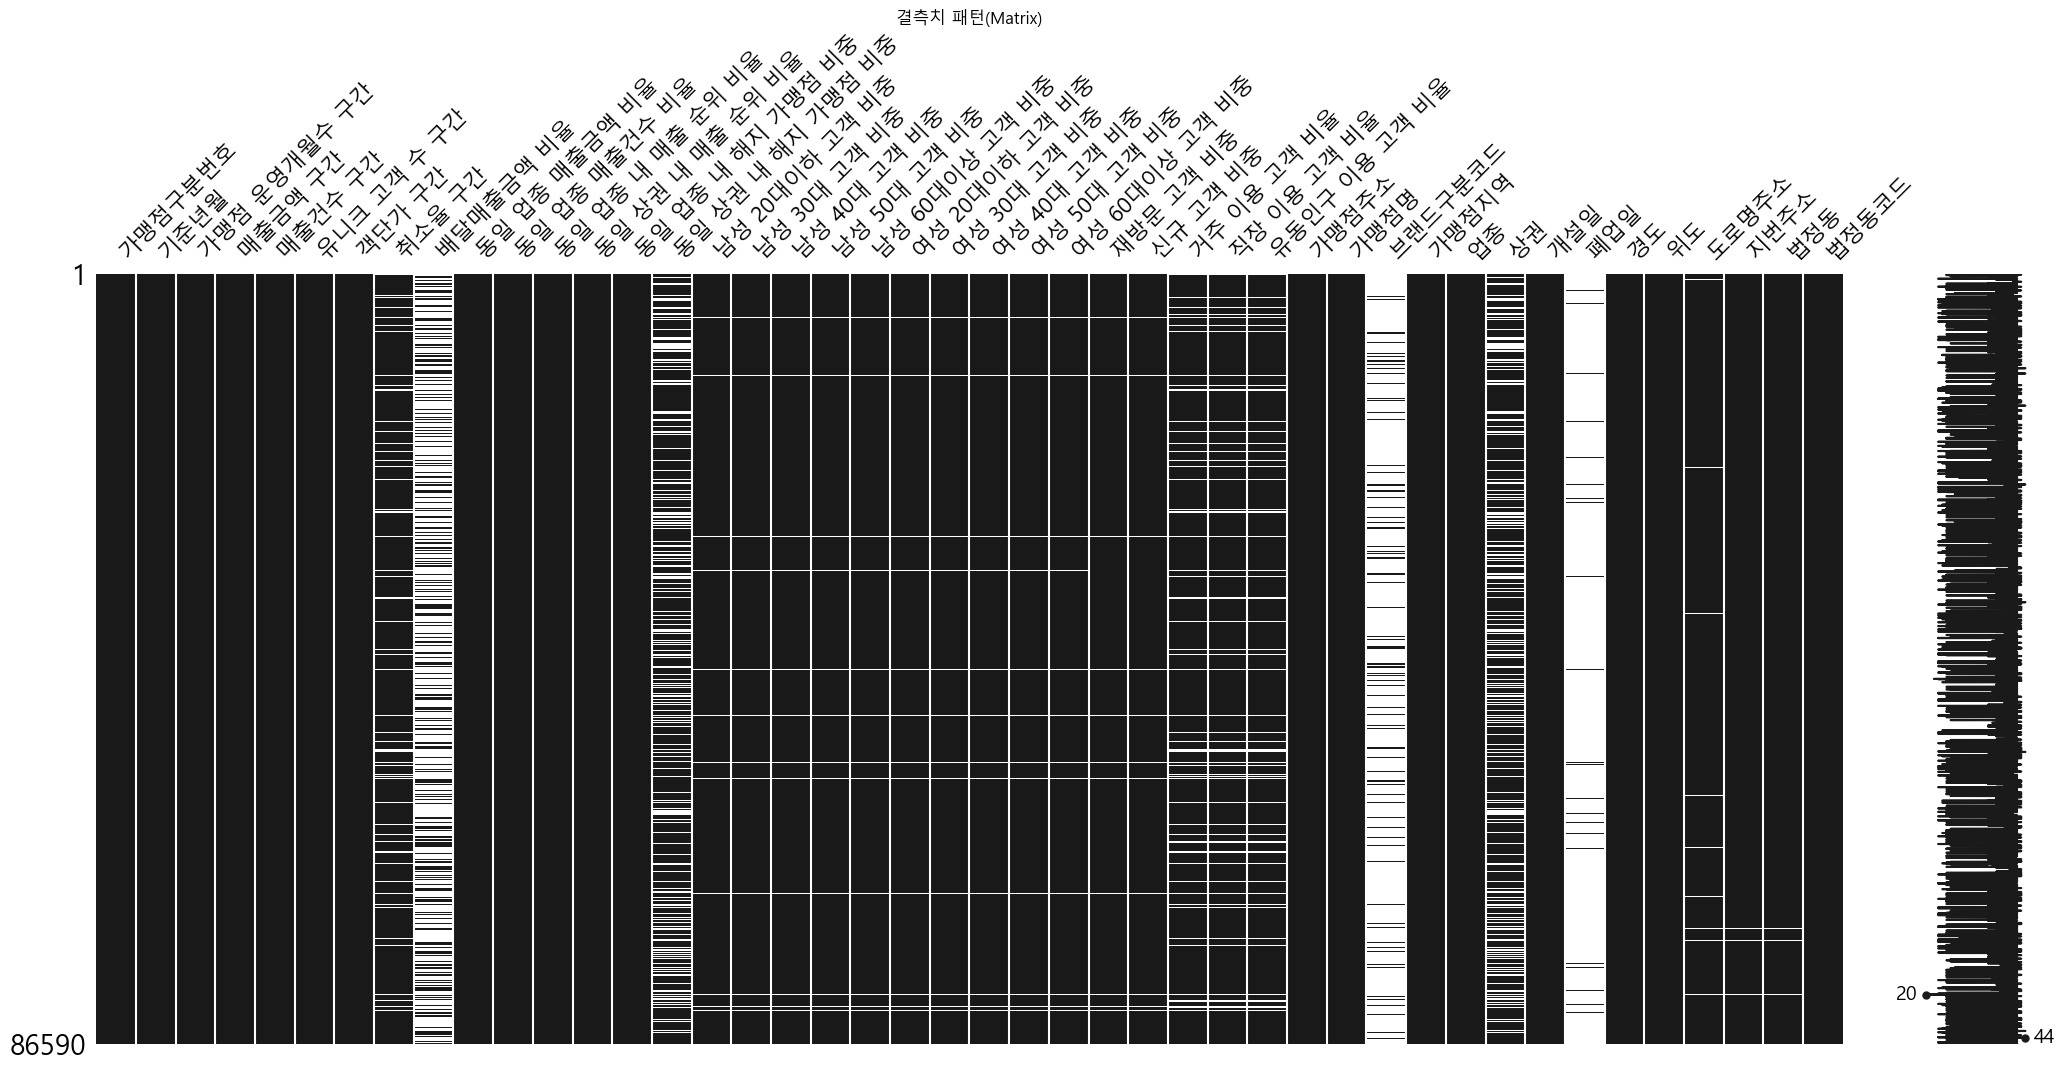

In [ ]:
# === 1. 행 기준 결측 분포 ===
plt.figure(figsize=(12,5))
msno.matrix(df, color=(0.1,0.1,0.1)) # 거의 흑백 느낌
plt.title("결측치 패턴(Matrix)")
plt.show()

<Figure size 800x600 with 0 Axes>

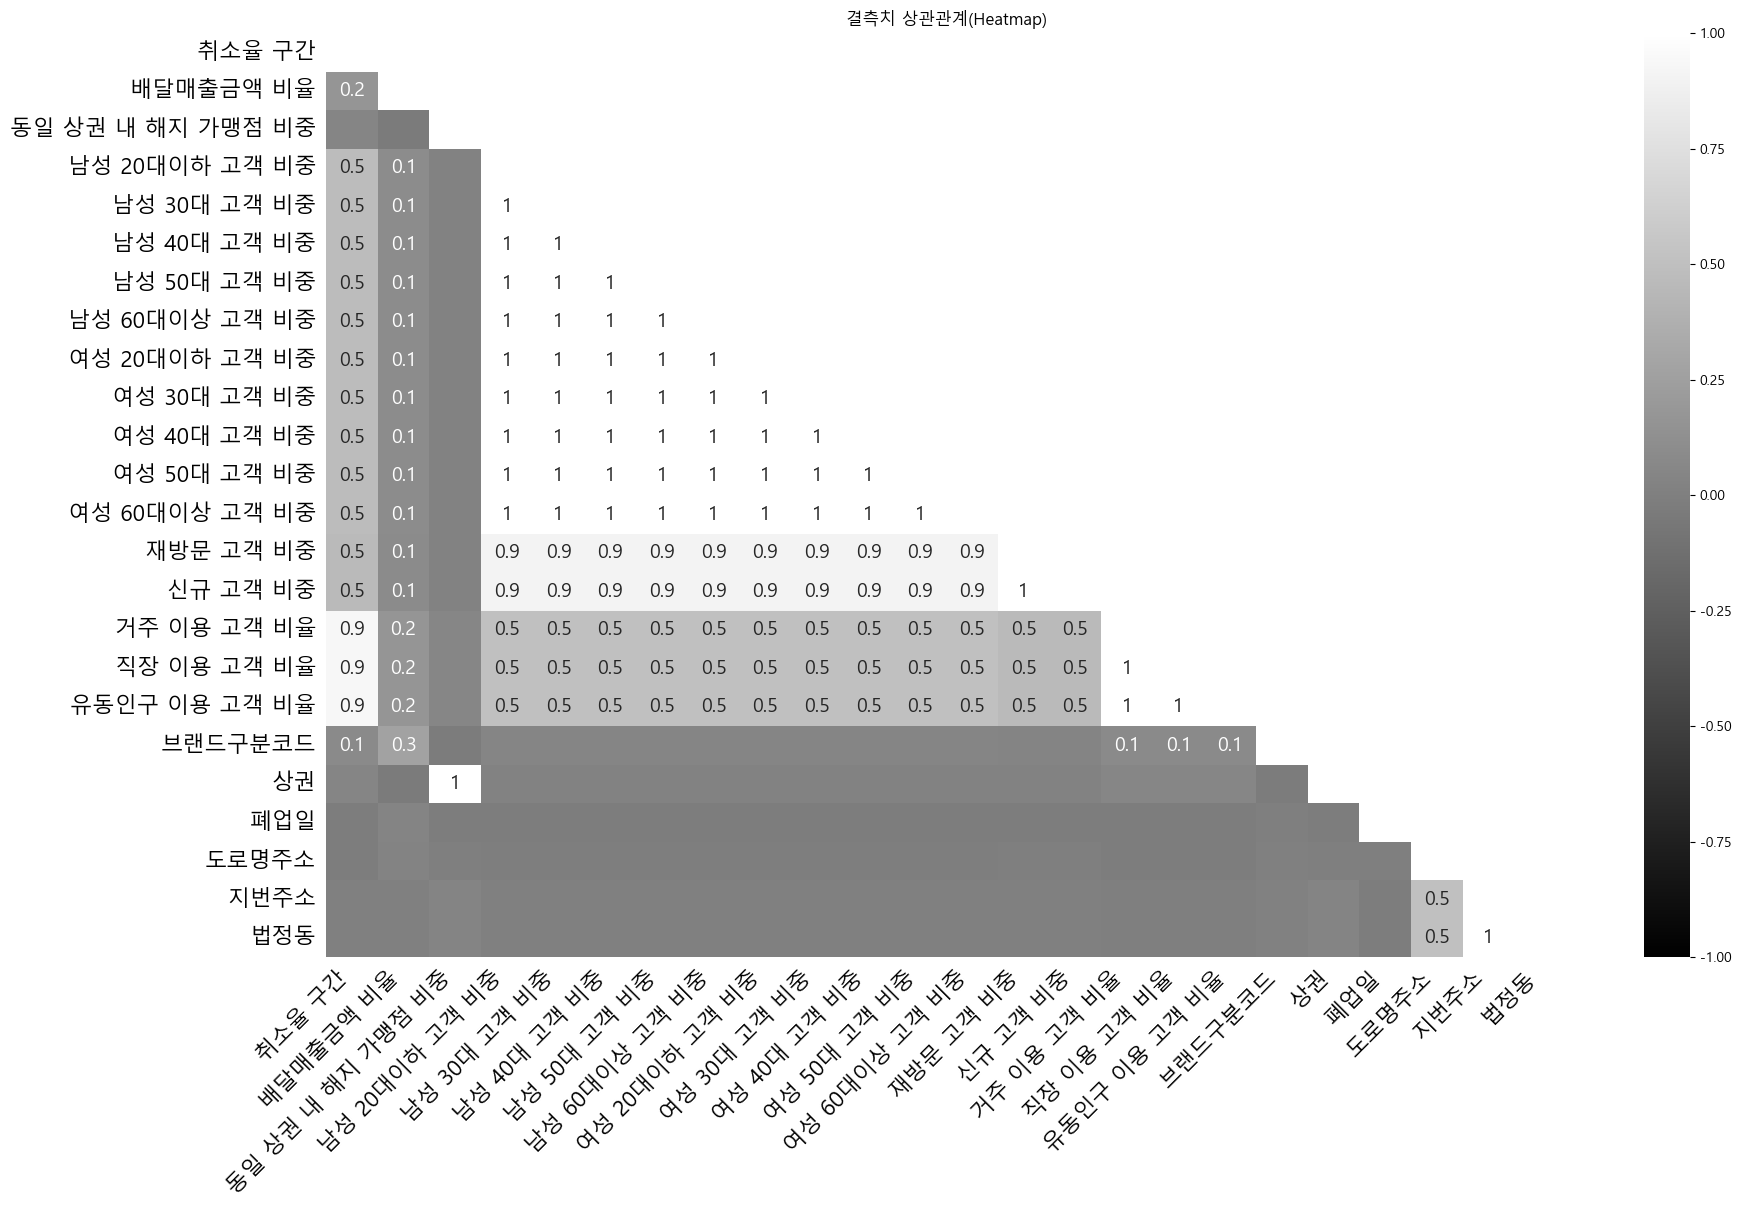

In [ ]:
# === 2. 컬럼 간 결측 상관관계 ===
plt.figure(figsize=(8,6))
msno.heatmap(df, cmap='gray')
plt.title("결측치 상관관계(Heatmap)")
plt.show()

### 1) 범주형

In [ ]:
# === [셀 1] 범주형 전처리만 ===
import pandas as pd
import numpy as np
import io
from pandas.api.types import is_datetime64_any_dtype

# df가 이미 존재한다고 가정
if 'df' not in globals() or df is None or getattr(df, 'empty', True):
    raise SystemExit("df가 메모리에 없습니다. 이전 셀에서 df를 로드한 뒤 다시 실행하세요.")

print(f"원본 데이터 크기: {df.shape}")
print("--- 범주형 전처리 시작 ---\n")

# ----------------------------------------------------
# 1. 폐업여부 변수 생성 (폐업일 기준)
# ----------------------------------------------------
print("--- 1. Target 변수('폐업여부') 생성 ---")
if "폐업일" in df.columns and not is_datetime64_any_dtype(df["폐업일"]):
    df["폐업일"] = pd.to_datetime(df["폐업일"], errors="coerce")
df["폐업여부"] = df["폐업일"].notna().astype(int).astype(str)
print(df["폐업여부"].value_counts(dropna=False))
print("--- 1. 폐업여부 변수 생성 완료 ---\n")

# ----------------------------------------------------
# 2. 가맹점 고정 정보 (Static) 범주형 결측 처리
# ----------------------------------------------------
print("--- 2. 가맹점 고정 정보 (Static) 결측치 채우기 ---")
static_cols = [
    "가맹점주소","가맹점명","가맹점지역","업종","상권","개설일",
    "경도","위도","도로명주소","지번주소","법정동","법정동코드","브랜드구분코드"
]

# '상권'과 '브랜드구분코드' 기본 채움
if "상권" in df.columns:
    df["상권"] = df["상권"].fillna("정보없음")
if "브랜드구분코드" in df.columns:
    df["브랜드구분코드"] = df["브랜드구분코드"].fillna("독립")

# 가맹점별 그룹 ffill/bfill
exist_static = [c for c in static_cols if c in df.columns]
if "가맹점구분번호" in df.columns and exist_static:
    df[exist_static] = df.groupby("가맹점구분번호")[exist_static].ffill().bfill()
print("--- 2. 고정 정보 채우기 완료 ---\n")

# ----------------------------------------------------
# 3. 월별 변동 데이터 중 '범주형' 처리 (ffill/bfill + 남은 결측 '정보없음')
# ----------------------------------------------------
print("  3. [범주형] 단순 ffill/bfill 방식 적용 중...")
ts_categorical_cols = [
    "가맹점 운영개월수 구간","매출금액 구간","매출건수 구간",
    "유니크 고객 수 구간","객단가 구간","취소율 구간"
]
exist_cat = [c for c in ts_categorical_cols if c in df.columns]
if "가맹점구분번호" in df.columns and exist_cat:
    df[exist_cat] = df.groupby("가맹점구분번호")[exist_cat].ffill().bfill()
    for c in exist_cat:
        df[c] = df[c].fillna("정보없음")
print("--- 범주형 시계열 처리 완료 ---\n")

# ----------------------------------------------------
# 4. 주소 컬럼 정리 (일부 드롭)
# ----------------------------------------------------
drop_cols = ["법정동코드","도로명주소","지번주소"]
cols_to_drop = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=cols_to_drop, errors="ignore")

keep_cols = ["법정동","위도","경도"]
print(f"삭제 완료 : {cols_to_drop}")
print(f"유지 확인 : {', '.join([c for c in keep_cols if c in df.columns])}")

print("\n[셀 1 완료] 범주형 전처리까지 마쳤습니다.")

원본 데이터 크기: (86590, 44)
--- 범주형 전처리 시작 ---

--- 1. Target 변수('폐업여부') 생성 ---
폐업여부
0    84256
1     2334
Name: count, dtype: int64
--- 1. 폐업여부 변수 생성 완료 ---

--- 2. 가맹점 고정 정보 (Static) 결측치 채우기 ---
--- 2. 고정 정보 채우기 완료 ---

  3. [범주형] 단순 ffill/bfill 방식 적용 중...
--- 범주형 시계열 처리 완료 ---

삭제 완료 : ['법정동코드', '도로명주소', '지번주소']
유지 확인 : 법정동, 위도, 경도

[셀 1 완료] 범주형 전처리까지 마쳤습니다.


### 2) 수치형

In [ ]:
# === [셀 2] (파일 로딩 없이) 수치형 전처리 + 저장 ===
import pandas as pd
import numpy as np
import io

# df 존재 확인
if "df" not in globals() or getattr(df, "empty", True):
    raise SystemExit("df가 비어있습니다. 셀 1을 먼저 실행하세요.")

print("--- 4. 월별 변동 데이터 (시계열) 결측치 채우기 ---")

# 4-1. 수치형(Numeric) 월별 데이터 (interpolate + ffill/bfill)
print("  4-1. [수치형] 하이브리드 방식 (interpolate + ffill/bfill) 적용 중...")
ts_numeric_cols = [
    "동일 업종 매출금액 비율", "동일 업종 매출건수 비율",
    "동일 업종 내 매출 순위 비율", "동일 상권 내 매출 순위 비율",
    "동일 업종 내 해지 가맹점 비중", "동일 상권 내 해지 가맹점 비중",
    "남성 20대이하 고객 비중", "남성 30대 고객 비중", "남성 40대 고객 비중", "남성 50대 고객 비중", "남성 60대이상 고객 비중",
    "여성 20대이하 고객 비중", "여성 30대 고객 비중", "여성 40대 고객 비중", "여성 50대 고객 비중", "여성 60대이상 고객 비중",
    "재방문 고객 비중", "신규 고객 비중",
    "거주 이용 고객 비율", "직장 이용 고객 비율", "유동인구 이용 고객 비율"
]
exist_num = [c for c in ts_numeric_cols if c in df.columns]

# 배달매출금액 비율 결측치 0
if "배달매출금액 비율" in df.columns:
    df["배달매출금액 비율"] = df["배달매출금액 비율"].fillna(0)

# 그룹별 보간 + ffill/bfill
if "가맹점구분번호" in df.columns and exist_num:
    grouped = df.groupby("가맹점구분번호")

    # 선형 보간 (중간값)
    df[exist_num] = (
        grouped[exist_num]
        .apply(lambda x: x.interpolate(method="linear", limit_direction="both", axis=0))
        .reset_index(level=0, drop=True)
    )

    # 앞뒤 결측 보완
    df[exist_num] = df.groupby("가맹점구분번호")[exist_num].ffill().bfill()

print("--- 4. 월별 변동 데이터 채우기 완료 ---\n")

# ----------------------------------------------------
# 5. 최종 결측치 처리
# ----------------------------------------------------
print("--- 5. 최종 결측치 처리 ---")
if exist_num:
    df[exist_num] = df[exist_num].fillna(0)

# 혹시 남아 있는 범주형 컬럼 결측 '정보없음'으로
ts_categorical_cols = [
    "가맹점 운영개월수 구간", "매출금액 구간", "매출건수 구간",
    "유니크 고객 수 구간", "객단가 구간", "취소율 구간"
]
exist_cat = [c for c in ts_categorical_cols if c in df.columns]
for c in exist_cat:
    df[c] = df[c].fillna("정보없음")

print("--- 5. 최종 결측치 처리 완료 ---\n")

# ----------------------------------------------------
# 6. 값 보정 (0~100 범위 클리핑)
# ----------------------------------------------------
print("--- 6. [보정] 고객 비중 데이터의 비현실적인 값 보정 ---")
customer_prop_cols = [
    "남성 20대이하 고객 비중", "남성 30대 고객 비중", "남성 40대 고객 비중", "남성 50대 고객 비중", "남성 60대이상 고객 비중",
    "여성 20대이하 고객 비중", "여성 30대 고객 비중", "여성 40대 고객 비중", "여성 50대 고객 비중", "여성 60대이상 고객 비중",
    "재방문 고객 비중", "신규 고객 비중",
    "거주 이용 고객 비율", "직장 이용 고객 비율", "유동인구 이용 고객 비율"
]
exist_prop = [c for c in customer_prop_cols if c in df.columns]
for col in exist_prop:
    df[col] = df[col].clip(0, 100)

if exist_prop:
    print(df[exist_prop].describe().loc[["min", "max"]])
print("--- 6. [보정] 완료 ---\n")

# ----------------------------------------------------
# 7. 결과 확인 및 저장
# ----------------------------------------------------
print("--- 7. 전처리 완료 후 데이터 정보 ---")
buffer = io.StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

print("\n--- 7. 전처리 완료 후 상위 5개 행 ---")
print(df.head())

--- 4. 월별 변동 데이터 (시계열) 결측치 채우기 ---
  4-1. [수치형] 하이브리드 방식 (interpolate + ffill/bfill) 적용 중...
--- 4. 월별 변동 데이터 채우기 완료 ---

--- 5. 최종 결측치 처리 ---
--- 5. 최종 결측치 처리 완료 ---

--- 6. [보정] 고객 비중 데이터의 비현실적인 값 보정 ---
     남성 20대이하 고객 비중  남성 30대 고객 비중  남성 40대 고객 비중  남성 50대 고객 비중  남성 60대이상 고객 비중  \
min             0.0           0.0           0.0           0.0             0.0   
max           100.0         100.0         100.0         100.0           100.0   

     여성 20대이하 고객 비중  여성 30대 고객 비중  여성 40대 고객 비중  여성 50대 고객 비중  여성 60대이상 고객 비중  \
min             0.0           0.0           0.0           0.0             0.0   
max           100.0         100.0         100.0         100.0           100.0   

     재방문 고객 비중  신규 고객 비중  거주 이용 고객 비율  직장 이용 고객 비율  유동인구 이용 고객 비율  
min        0.0       0.0          0.0          0.0            0.0  
max      100.0     100.0        100.0        100.0          100.0  
--- 6. [보정] 완료 ---

--- 7. 전처리 완료 후 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590

### 3) 주소 컬럼

In [ ]:
# === 불필요한 주소 컬럼 정리 ===
drop_cols = ["법정동코드", "도로명주소", "지번주소"]

# 실제 존재하는 컬럼만 삭제
cols_to_drop = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=cols_to_drop)

# 유지 확인
keep_cols = ["법정동", "위도", "경도"]
print(f"삭제 완료 ▶ {cols_to_drop}")
print(f"유지 확인 ▶ {', '.join([c for c in keep_cols if c in df.columns])}")
df[keep_cols].head()


삭제 완료 ▶ []
유지 확인 ▶ 법정동, 위도, 경도


,법정동,위도,경도
0,성수동1가,37.5454373515891,127.046360131211
1,성수동1가,37.5454373515891,127.046360131211
2,성수동1가,37.5454373515891,127.046360131211
3,성수동1가,37.5454373515891,127.046360131211
4,성수동1가,37.5454373515891,127.046360131211


In [ ]:
import pandas as pd
import numpy as np

print("=== 데이터 기본 정보 (−999999.9 포함 결측처리) ===")

# 결측치 정의: NaN + -999999.9
df_null = df.replace(-999999.9, np.nan)

# 기본 구조
rows, cols = df_null.shape

# dtype, 결측 개수, 결측률, 고유값 개수를 함께 표로 요약
info_table = pd.DataFrame({
    "컬럼명": df_null.columns,
    "데이터타입": df_null.dtypes.astype(str),
    "결측률(%)": (df_null.isna().mean() * 100).round(2),
    "결측개수": df_null.isna().sum(),
    "고유값수": df_null.nunique()
}).reset_index(drop=True)

print(f"행 개수: {rows:,} / 열 개수: {cols}")
display(info_table)


=== 데이터 기본 정보 (−999999.9 포함 결측처리) ===
행 개수: 86,590 / 열 개수: 42


,컬럼명,데이터타입,결측률(%),결측개수,고유값수
0,가맹점구분번호,object,0.0,0,4185
1,기준년월,int64,0.0,0,24
2,가맹점 운영개월수 구간,object,0.0,0,6
3,매출금액 구간,object,0.0,0,6
4,매출건수 구간,object,0.0,0,6
5,유니크 고객 수 구간,object,0.0,0,6
6,객단가 구간,object,0.0,0,6
7,취소율 구간,object,0.0,0,6
8,배달매출금액 비율,float64,0.0,0,1002
9,동일 업종 매출금액 비율,float64,0.0,0,7175


## 3. 파생변수 생성

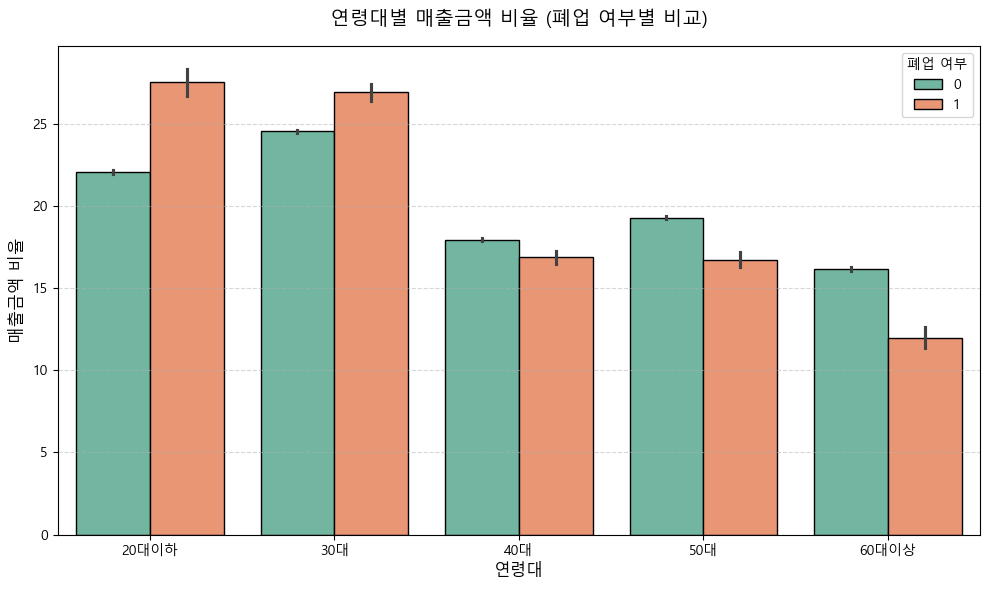

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# "폐업여부" 컬럼이 'O' / 'X' 형태라고 가정
age_cols = [
    "남성 20대이하 고객 비중","남성 30대 고객 비중","남성 40대 고객 비중","남성 50대 고객 비중","남성 60대이상 고객 비중",
    "여성 20대이하 고객 비중","여성 30대 고객 비중","여성 40대 고객 비중","여성 50대 고객 비중","여성 60대이상 고객 비중"
]

# 연령대 합산 (남+여)
df["20대이하"] = df["남성 20대이하 고객 비중"] + df["여성 20대이하 고객 비중"]
df["30대"]     = df["남성 30대 고객 비중"]     + df["여성 30대 고객 비중"]
df["40대"]     = df["남성 40대 고객 비중"]     + df["여성 40대 고객 비중"]
df["50대"]     = df["남성 50대 고객 비중"]     + df["여성 50대 고객 비중"]
df["60대이상"] = df["남성 60대이상 고객 비중"] + df["여성 60대이상 고객 비중"]

# melt로 long-form 변환
plot_df = df.melt(
    id_vars=["폐업여부"],
    value_vars=["20대이하","30대","40대","50대","60대이상"],
    var_name="연령대", value_name="고객비중"
)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="연령대", y="고객비중",
    hue="폐업여부",
    palette="Set2",
    edgecolor="black"
)

plt.title("연령대별 매출금액 비율 (폐업 여부별 비교)", fontsize=14, pad=15)
plt.xlabel("연령대", fontsize=12)
plt.ylabel("매출금액 비율", fontsize=12)
plt.legend(title="폐업 여부", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# === 성별·연령 파생변수만 생성 ===
import numpy as np
import pandas as pd

df_fe = df.copy()

# 필요한 원천 컬럼
age_m = ["남성 20대이하 고객 비중","남성 30대 고객 비중","남성 40대 고객 비중","남성 50대 고객 비중","남성 60대이상 고객 비중"]
age_f = ["여성 20대이하 고객 비중","여성 30대 고객 비중","여성 40대 고객 비중","여성 50대 고객 비중","여성 60대이상 고객 비중"]
need_cols = age_m + age_f

# 빠진 컬럼은 0.0으로 만들어 채워넣기(경고 출력)
missing = [c for c in need_cols if c not in df_fe.columns]
if missing:
    print(f"[WARN] 빠진 컬럼이 있어 0.0으로 대체합니다: {missing}")
    for c in missing:
        df_fe[c] = 0.0

# 결측 보정
df_fe[need_cols] = df_fe[need_cols].fillna(0.0)

# 성별 합계 및 전체(0-division 방지)
male_sum = df_fe[age_m].sum(axis=1)
fema_sum = df_fe[age_f].sum(axis=1)
total_age = male_sum + fema_sum
total_age_safe = total_age.replace(0, np.nan)

# (1) 성별 합계 비율
df_fe["남성합계비율"] = (male_sum / total_age_safe).fillna(0.0)
df_fe["여성합계비율"] = (fema_sum / total_age_safe).fillna(0.0)

# (2) 연령대별 합계 비율
age20 = df_fe["남성 20대이하 고객 비중"] + df_fe["여성 20대이하 고객 비중"]
age30 = df_fe["남성 30대 고객 비중"]     + df_fe["여성 30대 고객 비중"]
age40 = df_fe["남성 40대 고객 비중"]     + df_fe["여성 40대 고객 비중"]
age50 = df_fe["남성 50대 고객 비중"]     + df_fe["여성 50대 고객 비중"]
age60 = df_fe["남성 60대이상 고객 비중"] + df_fe["여성 60대이상 고객 비중"]


# (3) 2030합 / 405060합
df_fe["2030합비율"]    = ((age20 + age30) / total_age_safe).fillna(0.0)
df_fe["405060합비율"]  = ((age40 + age50 + age60) / total_age_safe).fillna(0.0)

# 최종 유지 컬럼만 concat
keep = [
    "남성합계비율","여성합계비율",
    "2030합비율","405060합비율",
]
print(f"생성된 성별·연령 파생 피처 {len(keep)}개")
display(df_fe[keep].head(10))

# 원본 df에 붙이기
df = pd.concat([df, df_fe[keep]], axis=1)


생성된 성별·연령 파생 피처 4개


,남성합계비율,여성합계비율,2030합비율,405060합비율
0,0.000,1.000,0.000,1.000
1,0.000,1.000,0.000,1.000
2,0.000,1.000,0.000,1.000
3,0.720,0.280,0.500,0.500
4,0.707,0.293,0.667,0.333
5,0.722,0.278,0.750,0.250
6,0.722,0.278,0.750,0.250
7,0.722,0.278,0.750,0.250
8,0.760,0.240,0.600,0.400
9,0.760,0.240,0.600,0.400


In [ ]:
df.to_csv("data\smallbiz-data-preprocessed.csv", index=False, encoding="utf-8-sig")


## 4. 데이터 시각화

In [ ]:
df = pd.read_csv("data\smallbiz-data-preprocessed.csv")

C:\Users\yura1\AppData\Local\Temp\ipykernel_5576\1874719646.py:1: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data\smallbiz-data-preprocessed.csv")


In [ ]:
# =========================================
# 전처리를 위한 EDA (df 기반)
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-muted")


In [ ]:
df.columns

Index(['가맹점구분번호', '기준년월', '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간',
       '객단가 구간', '취소율 구간', '배달매출금액 비율', '동일 업종 매출금액 비율', '동일 업종 매출건수 비율',
       '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중',
       '동일 상권 내 해지 가맹점 비중', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중',
       '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중',
       '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중', '재방문 고객 비중',
       '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율', '가맹점주소',
       '가맹점명', '브랜드구분코드', '가맹점지역', '업종', '상권', '개설일', '폐업일', '경도', '위도', '법정동',
       '폐업여부', '20대이하', '30대', '40대', '50대', '60대이상', '남성합계비율', '여성합계비율',
       '2030합비율', '405060합비율'],
      dtype='object')

[y 후보] ['매출금액 구간', '매출건수 구간', '배달매출금액 비율', '동일 업종 매출금액 비율', '동일 업종 매출건수 비율', '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '폐업일', '폐업여부']
[x 후보 수] 36


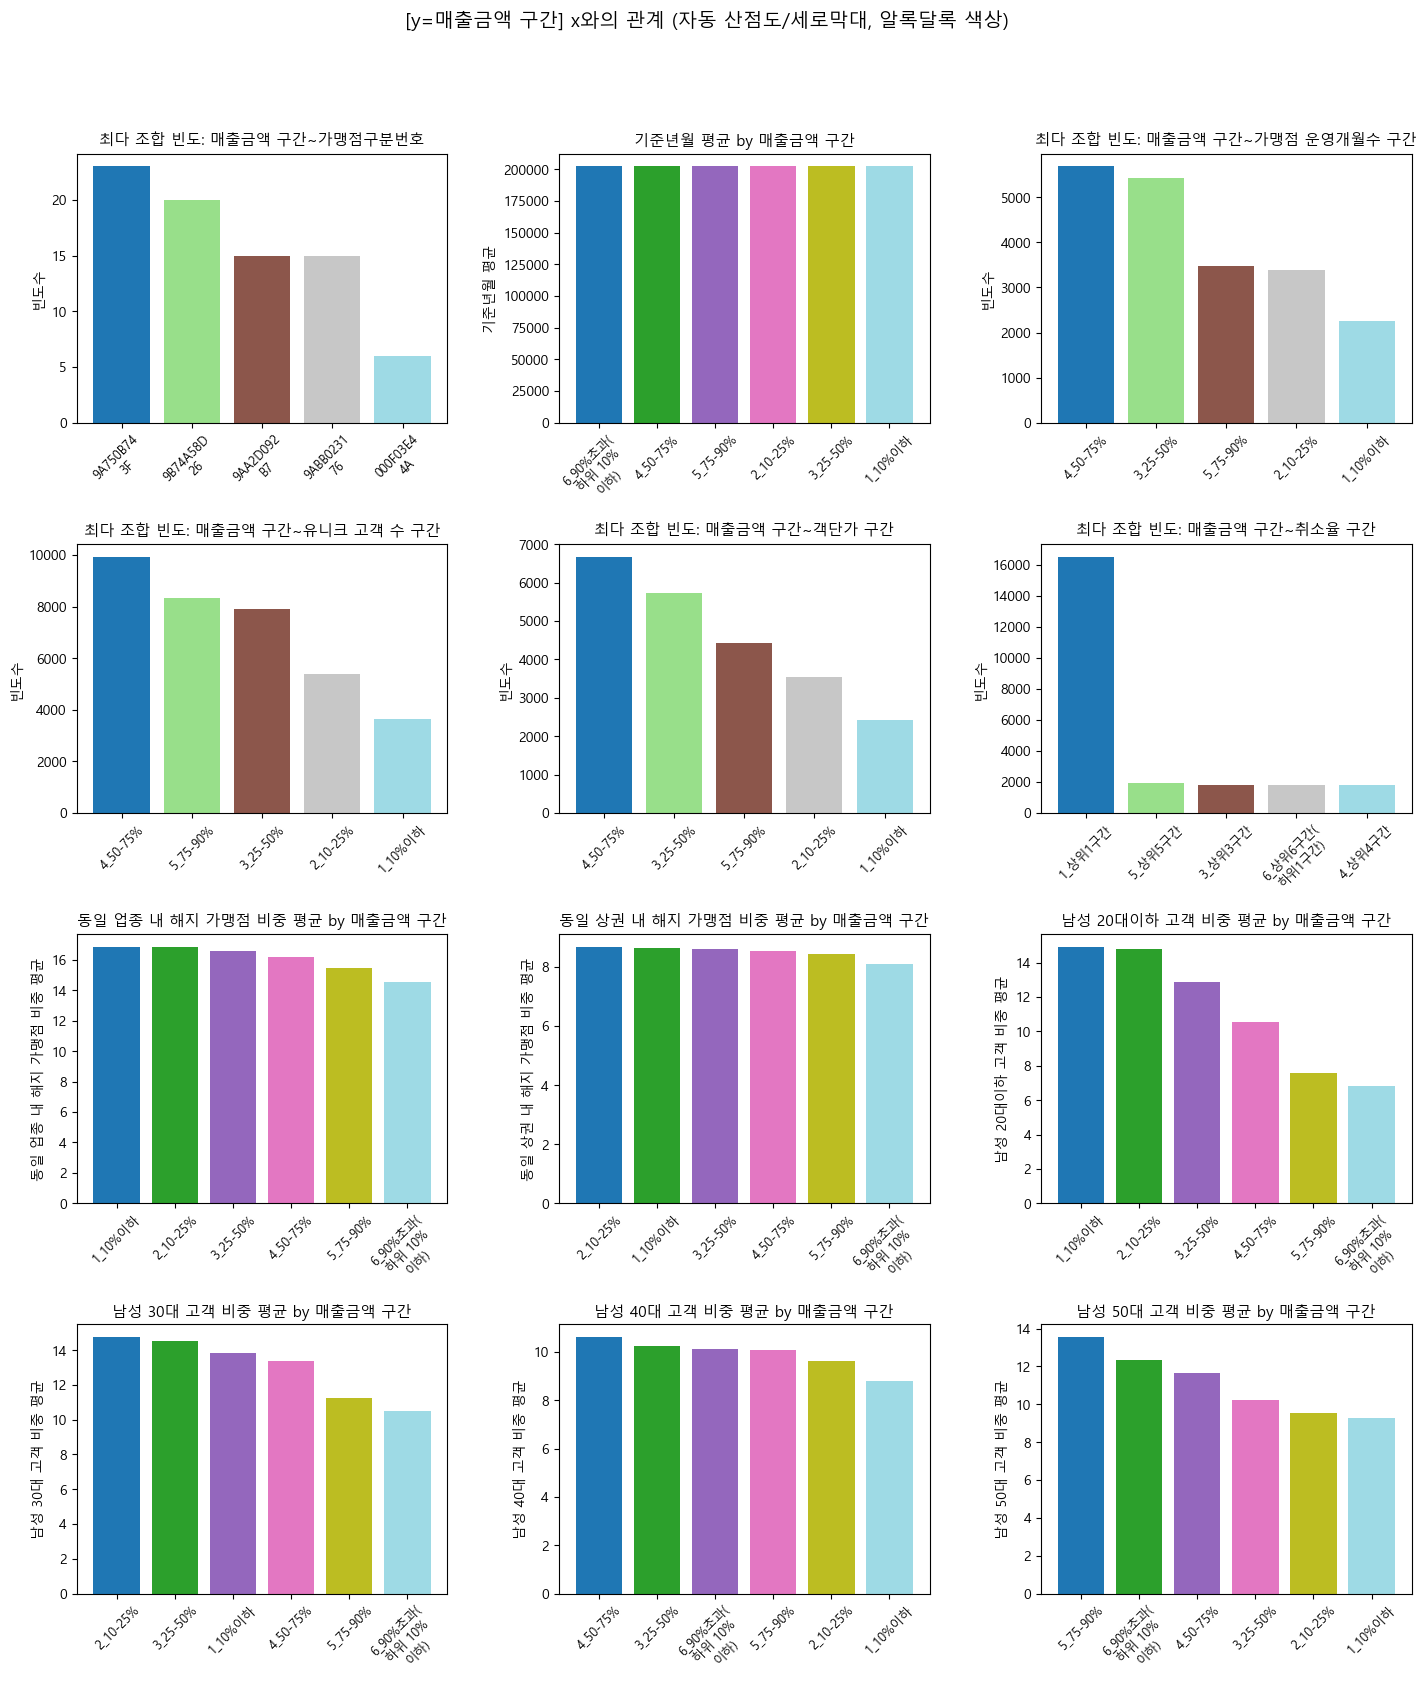

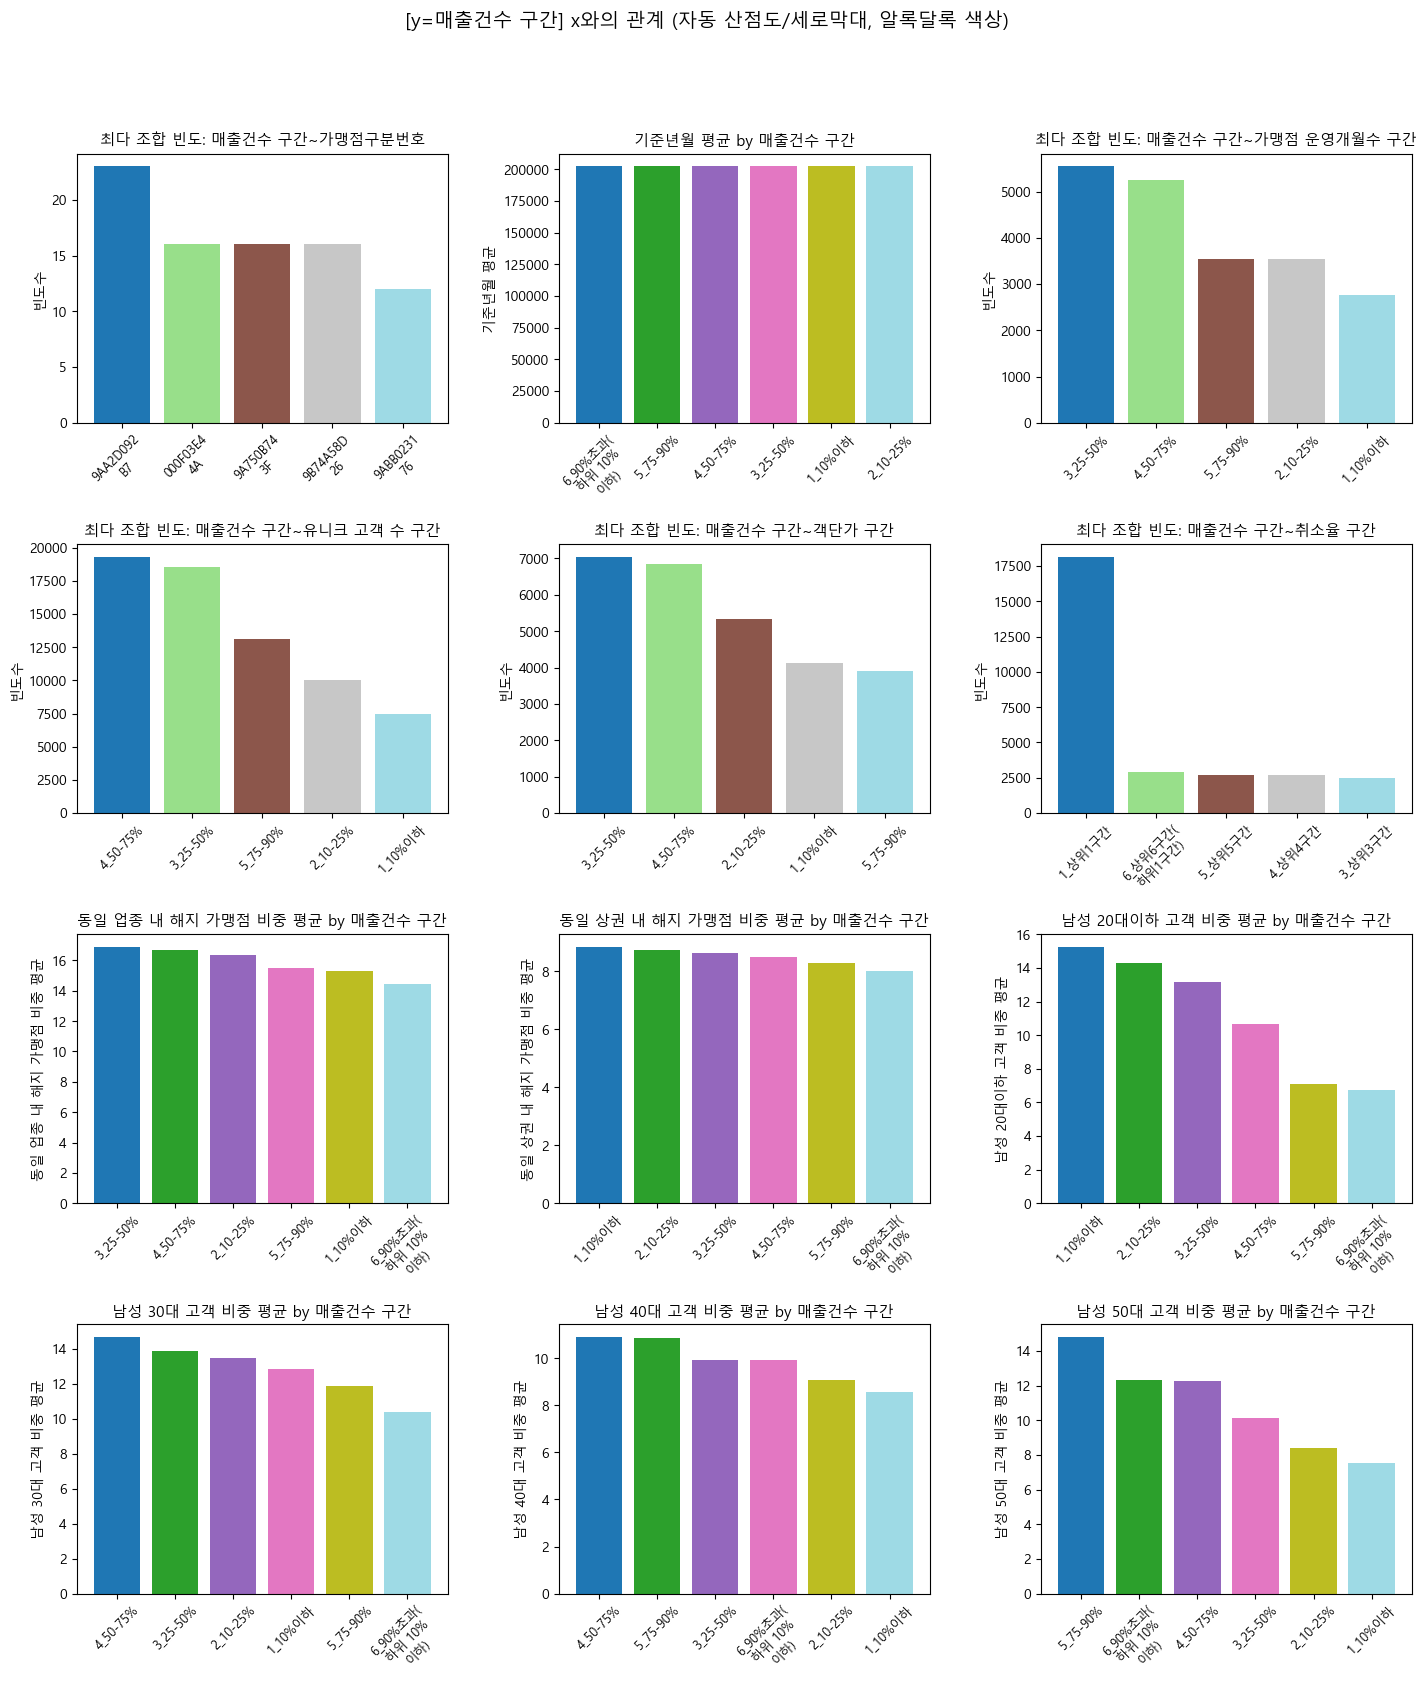

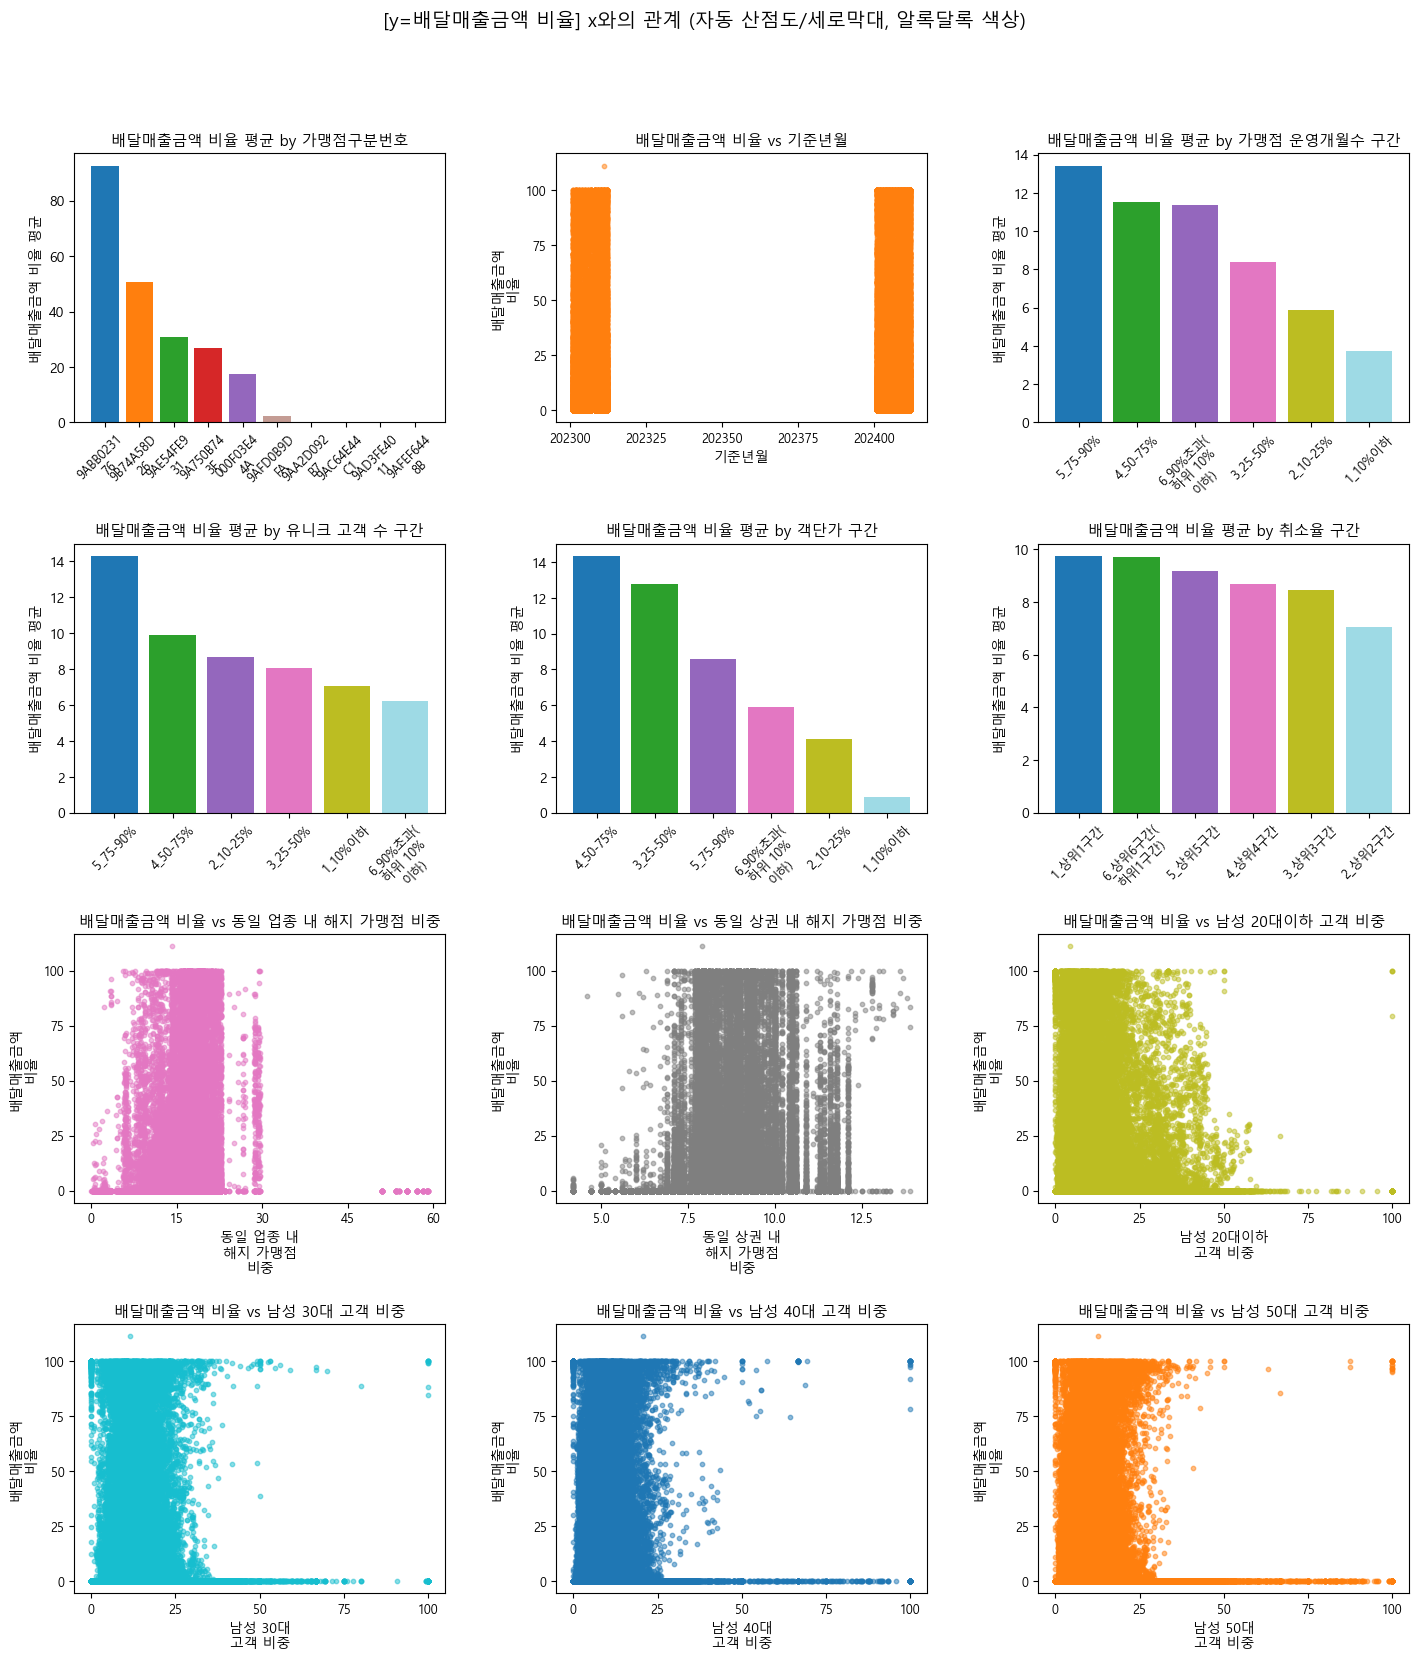

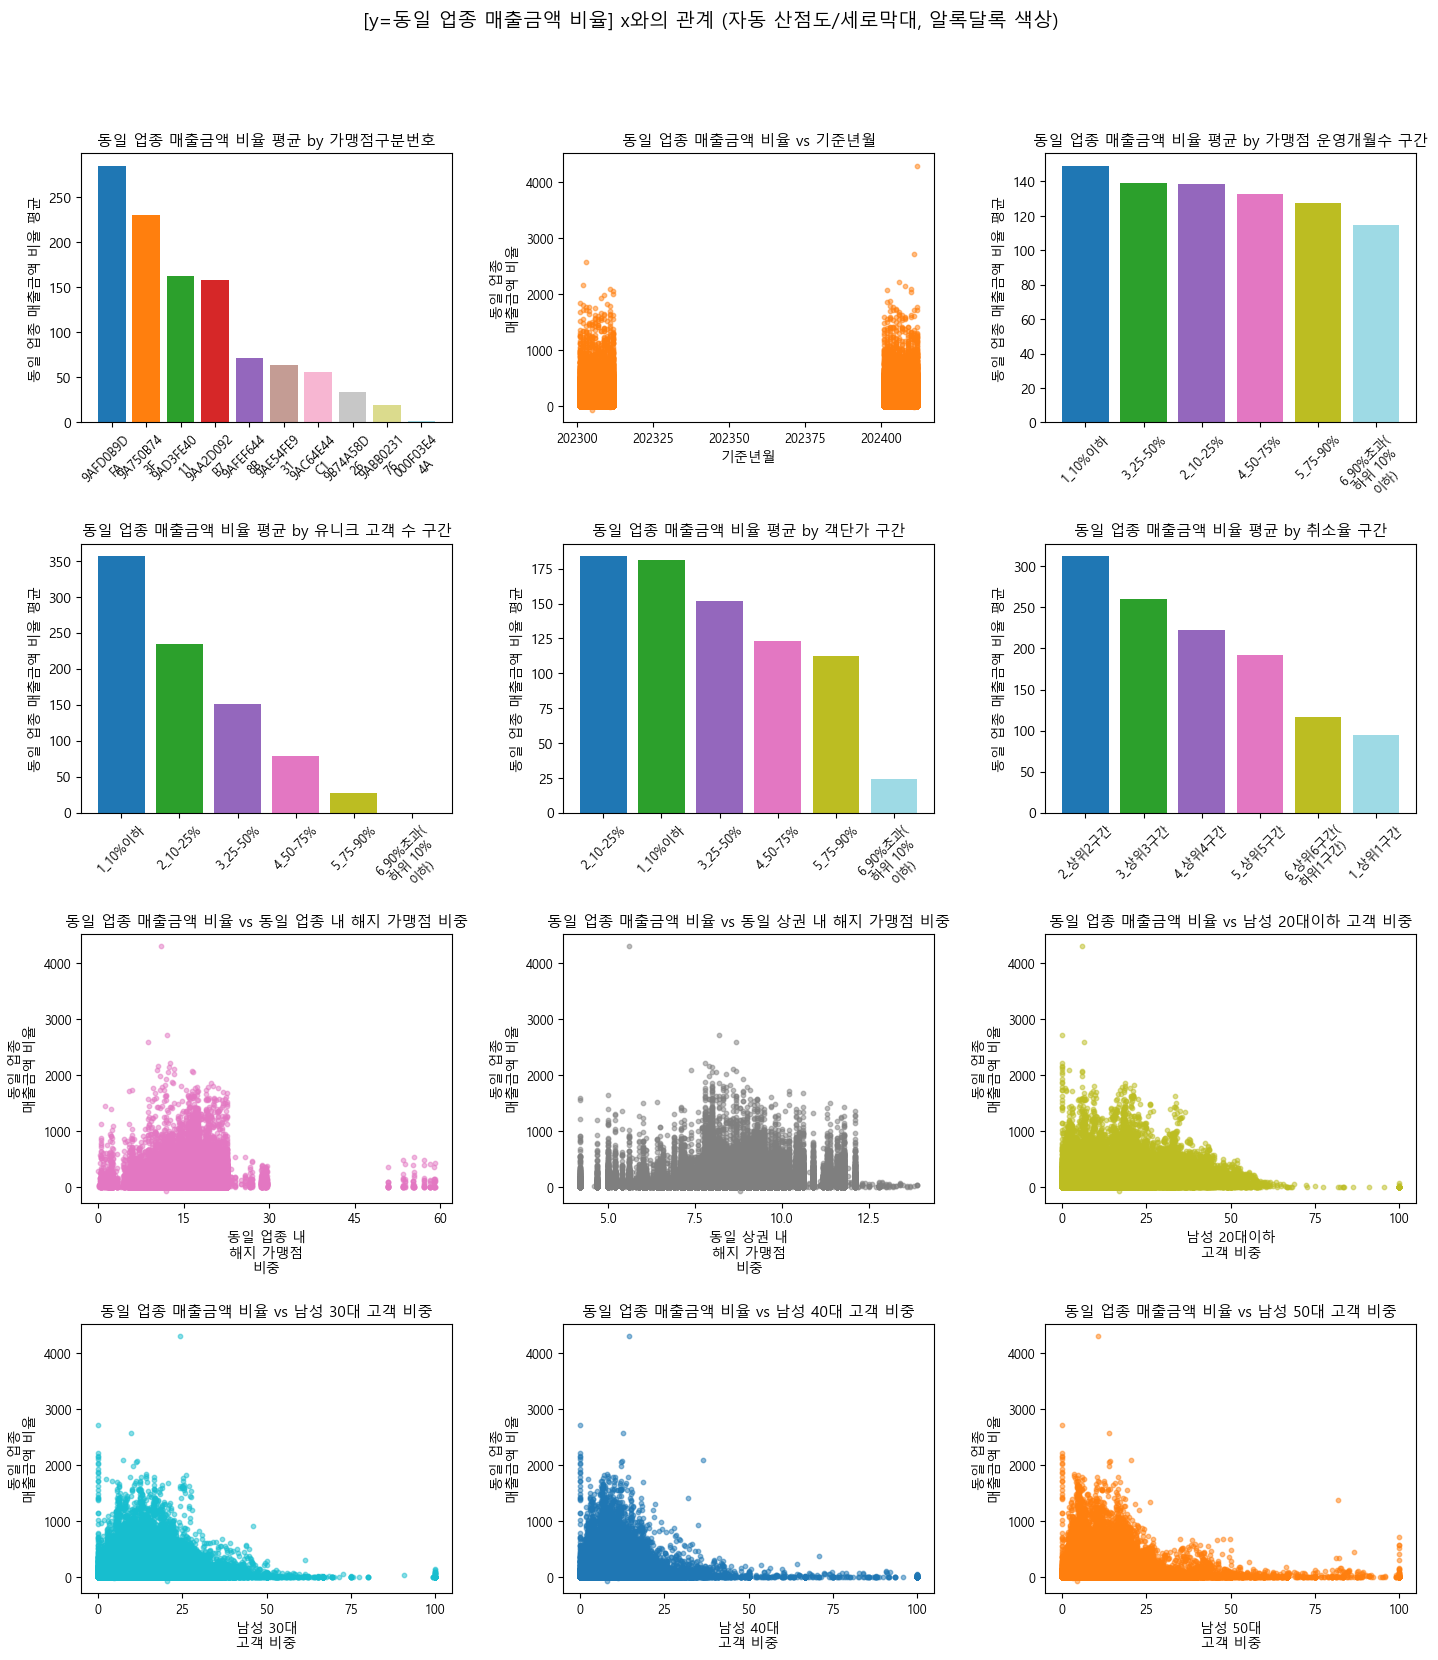

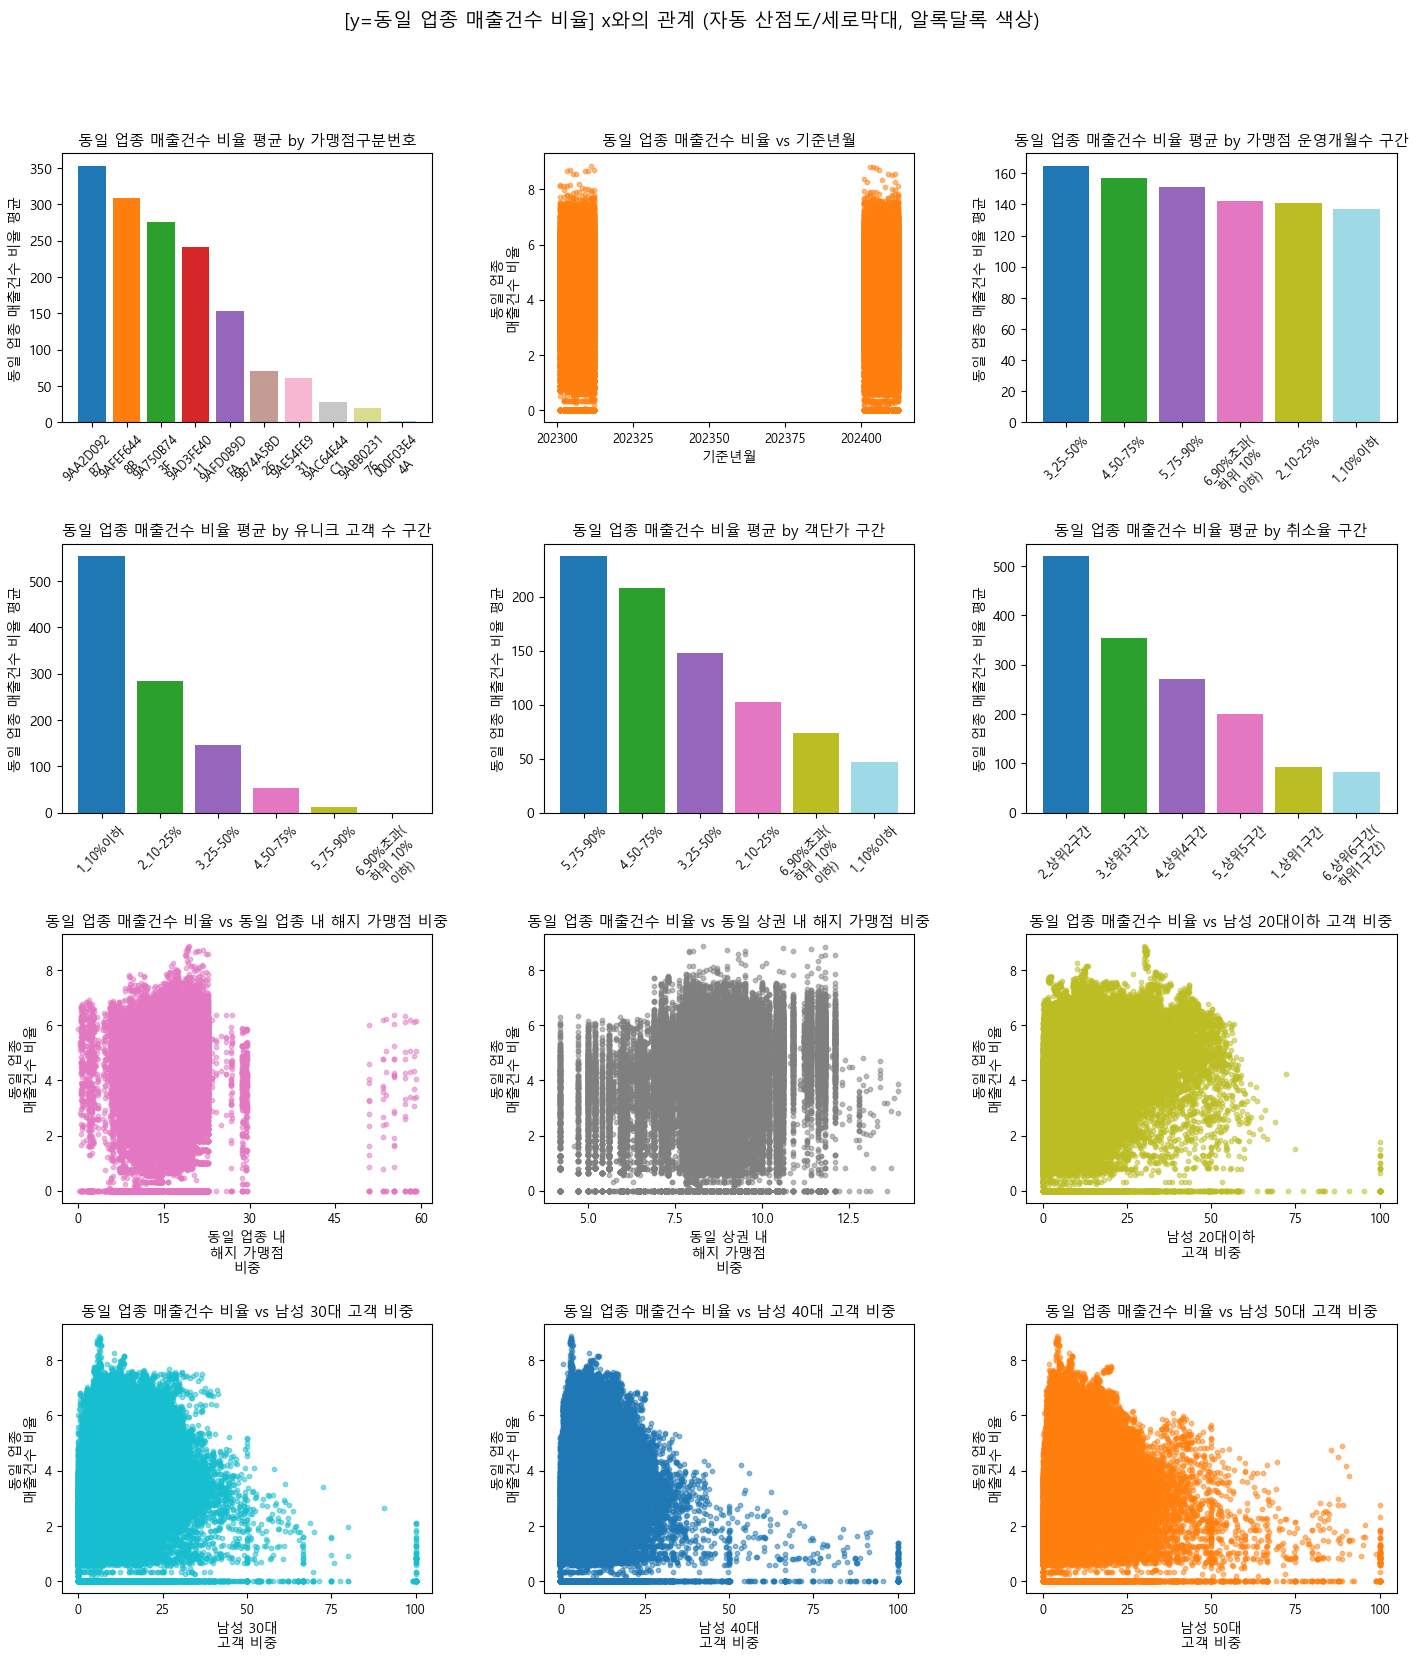

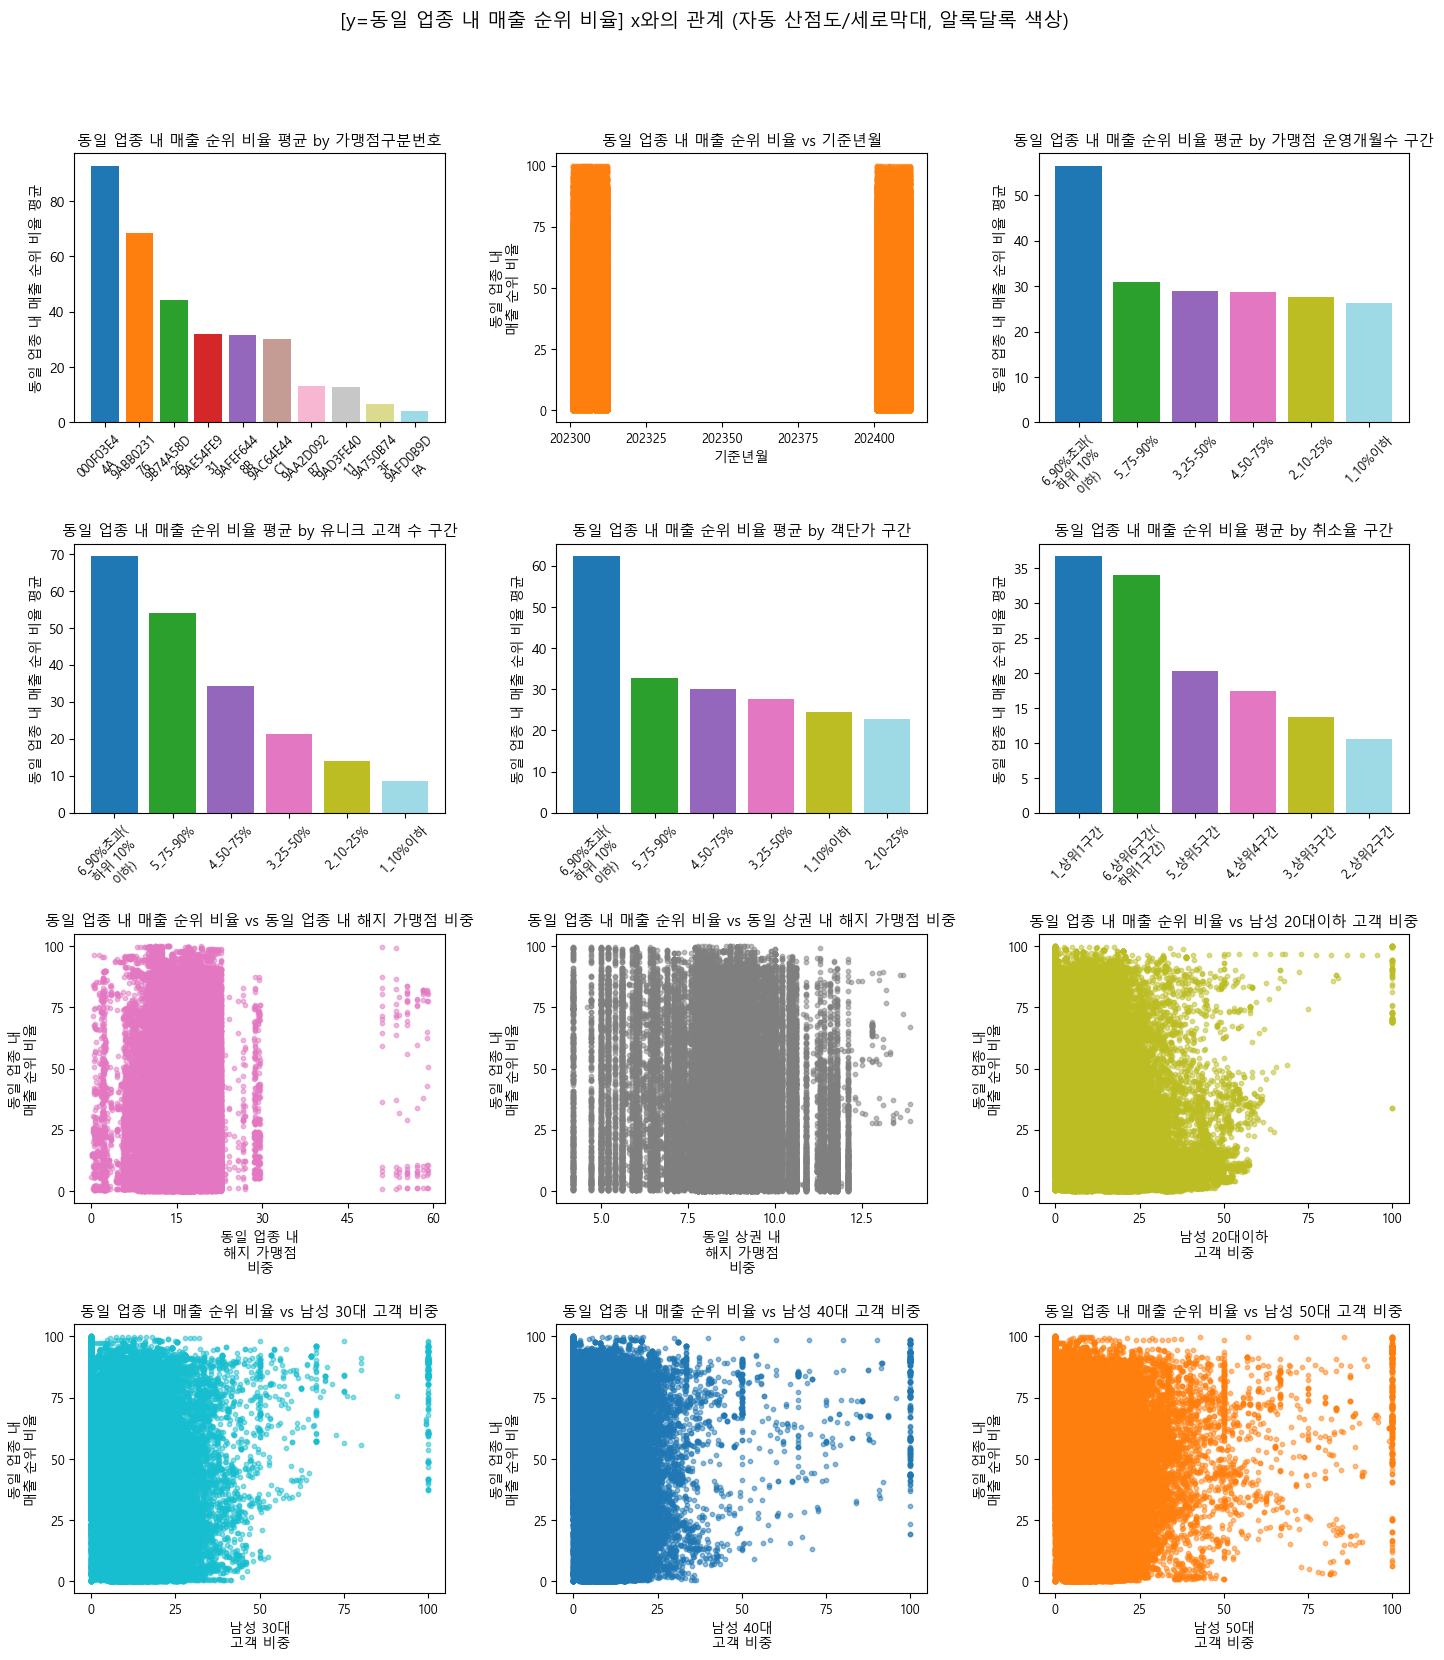

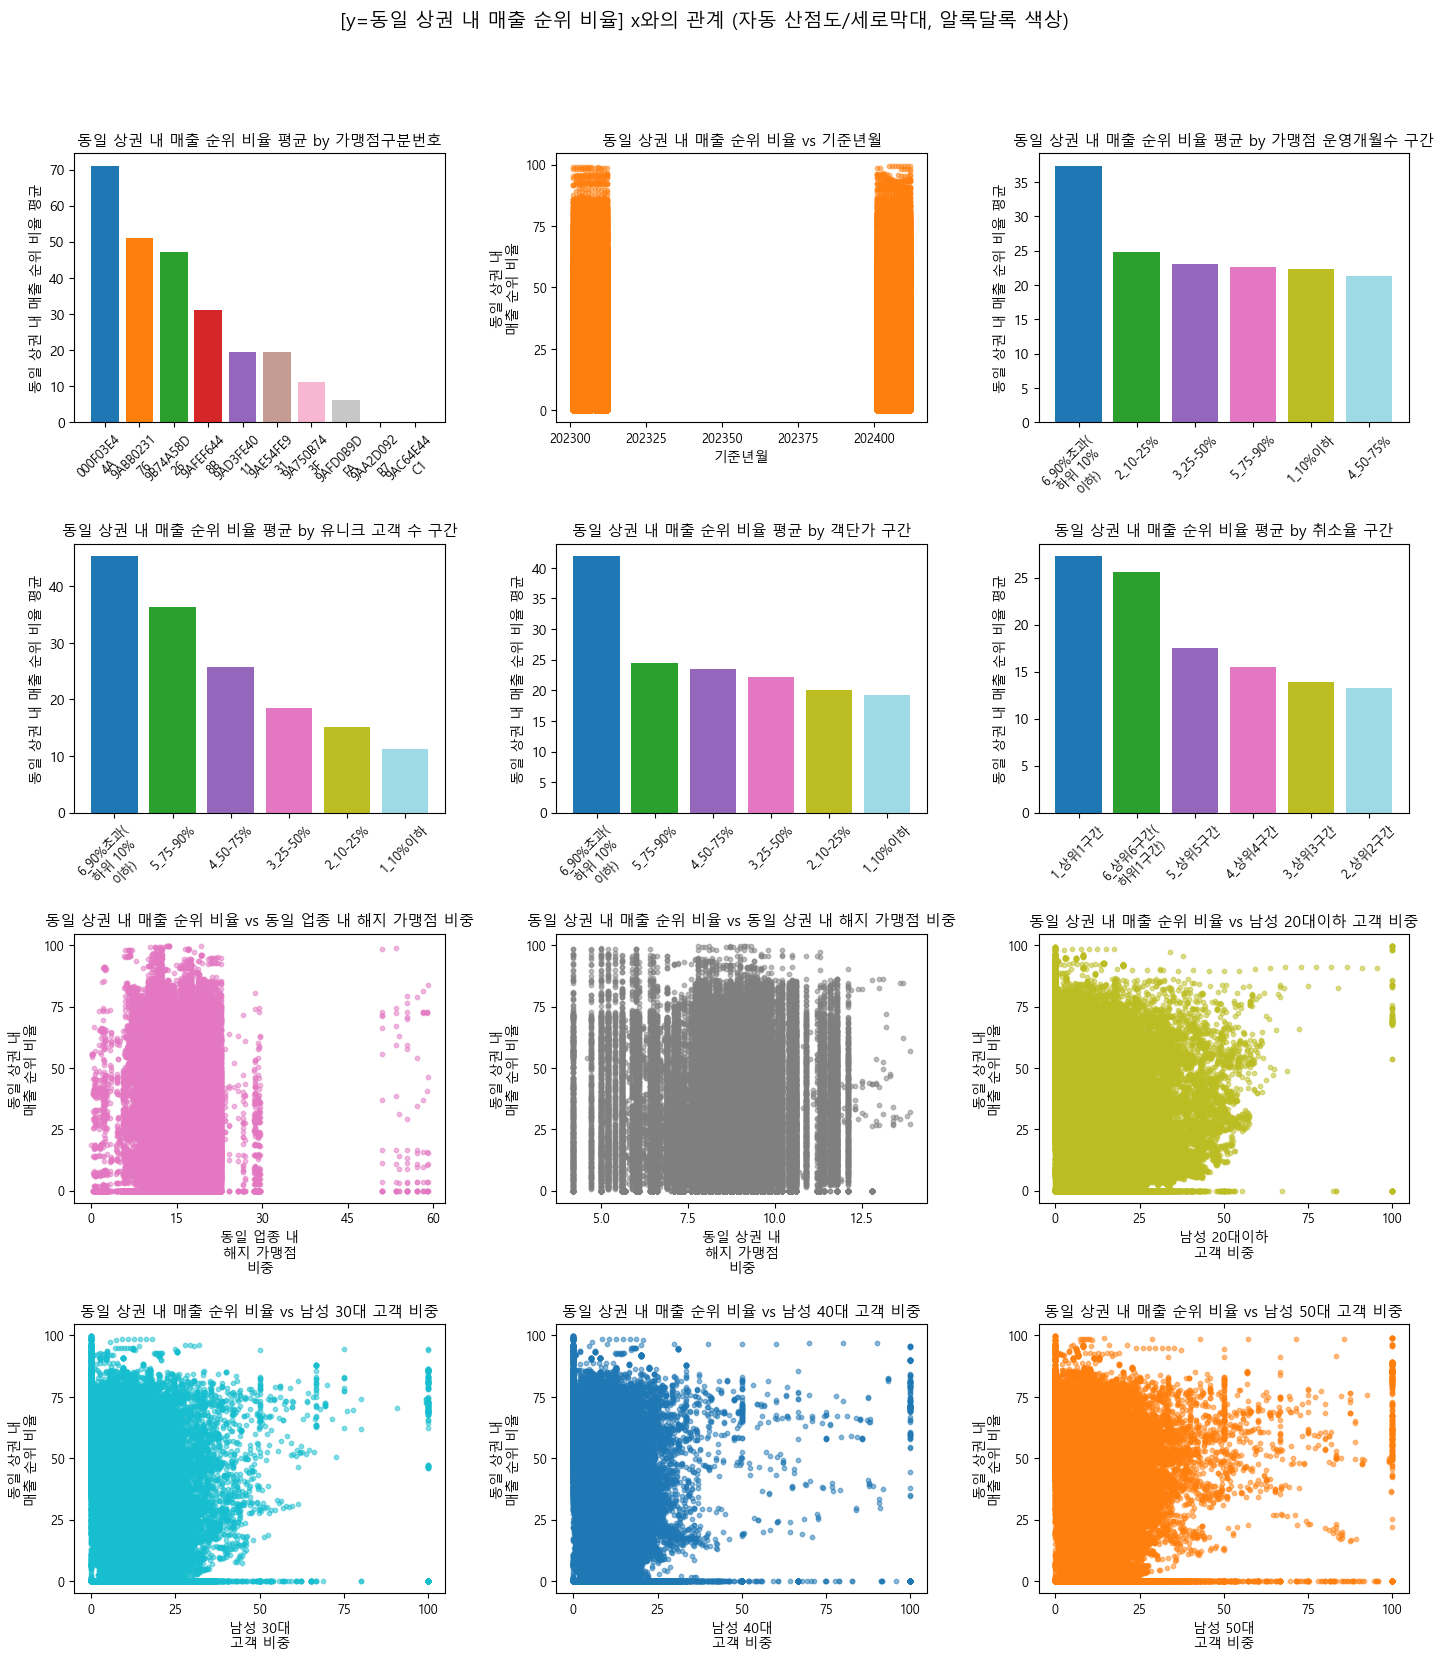

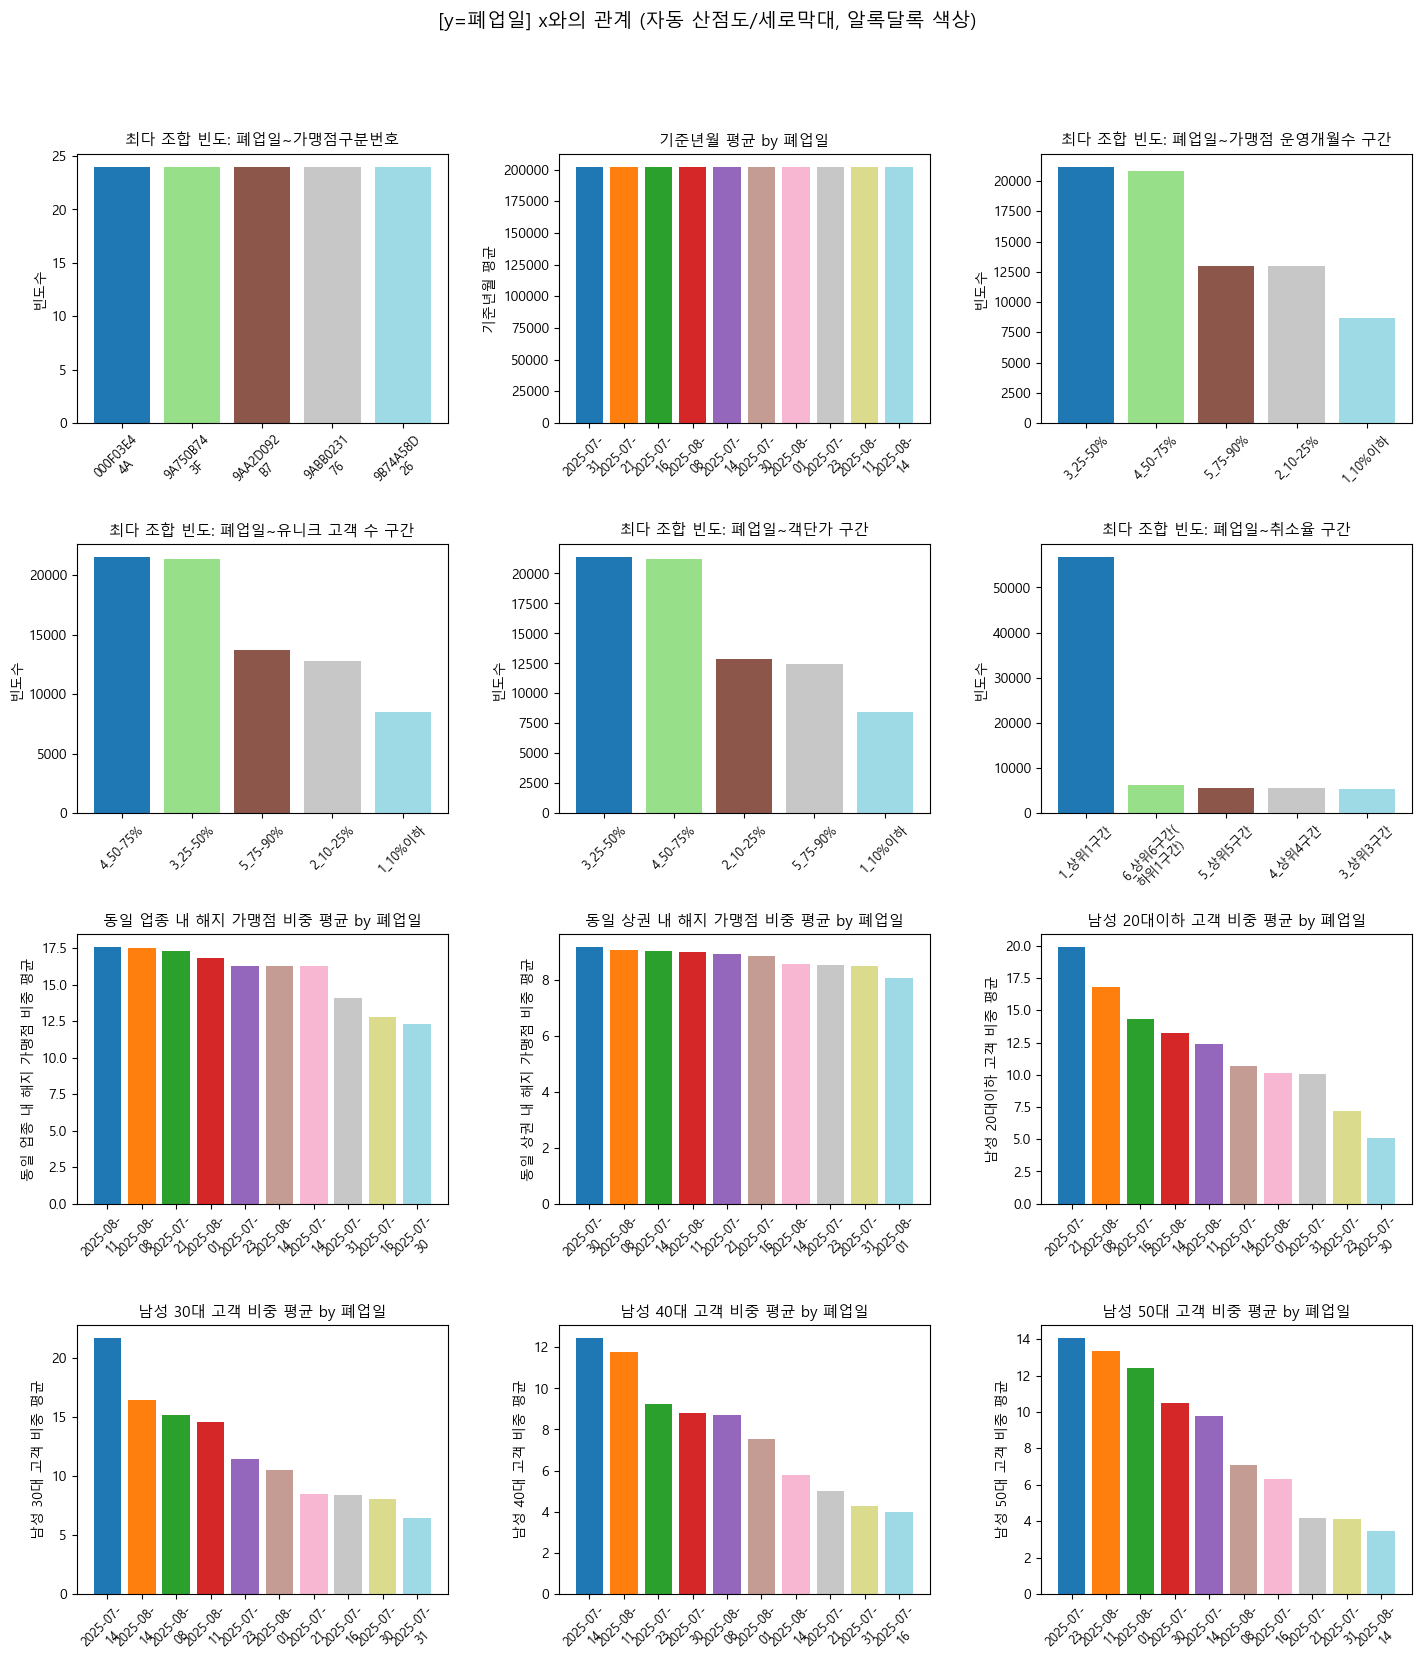

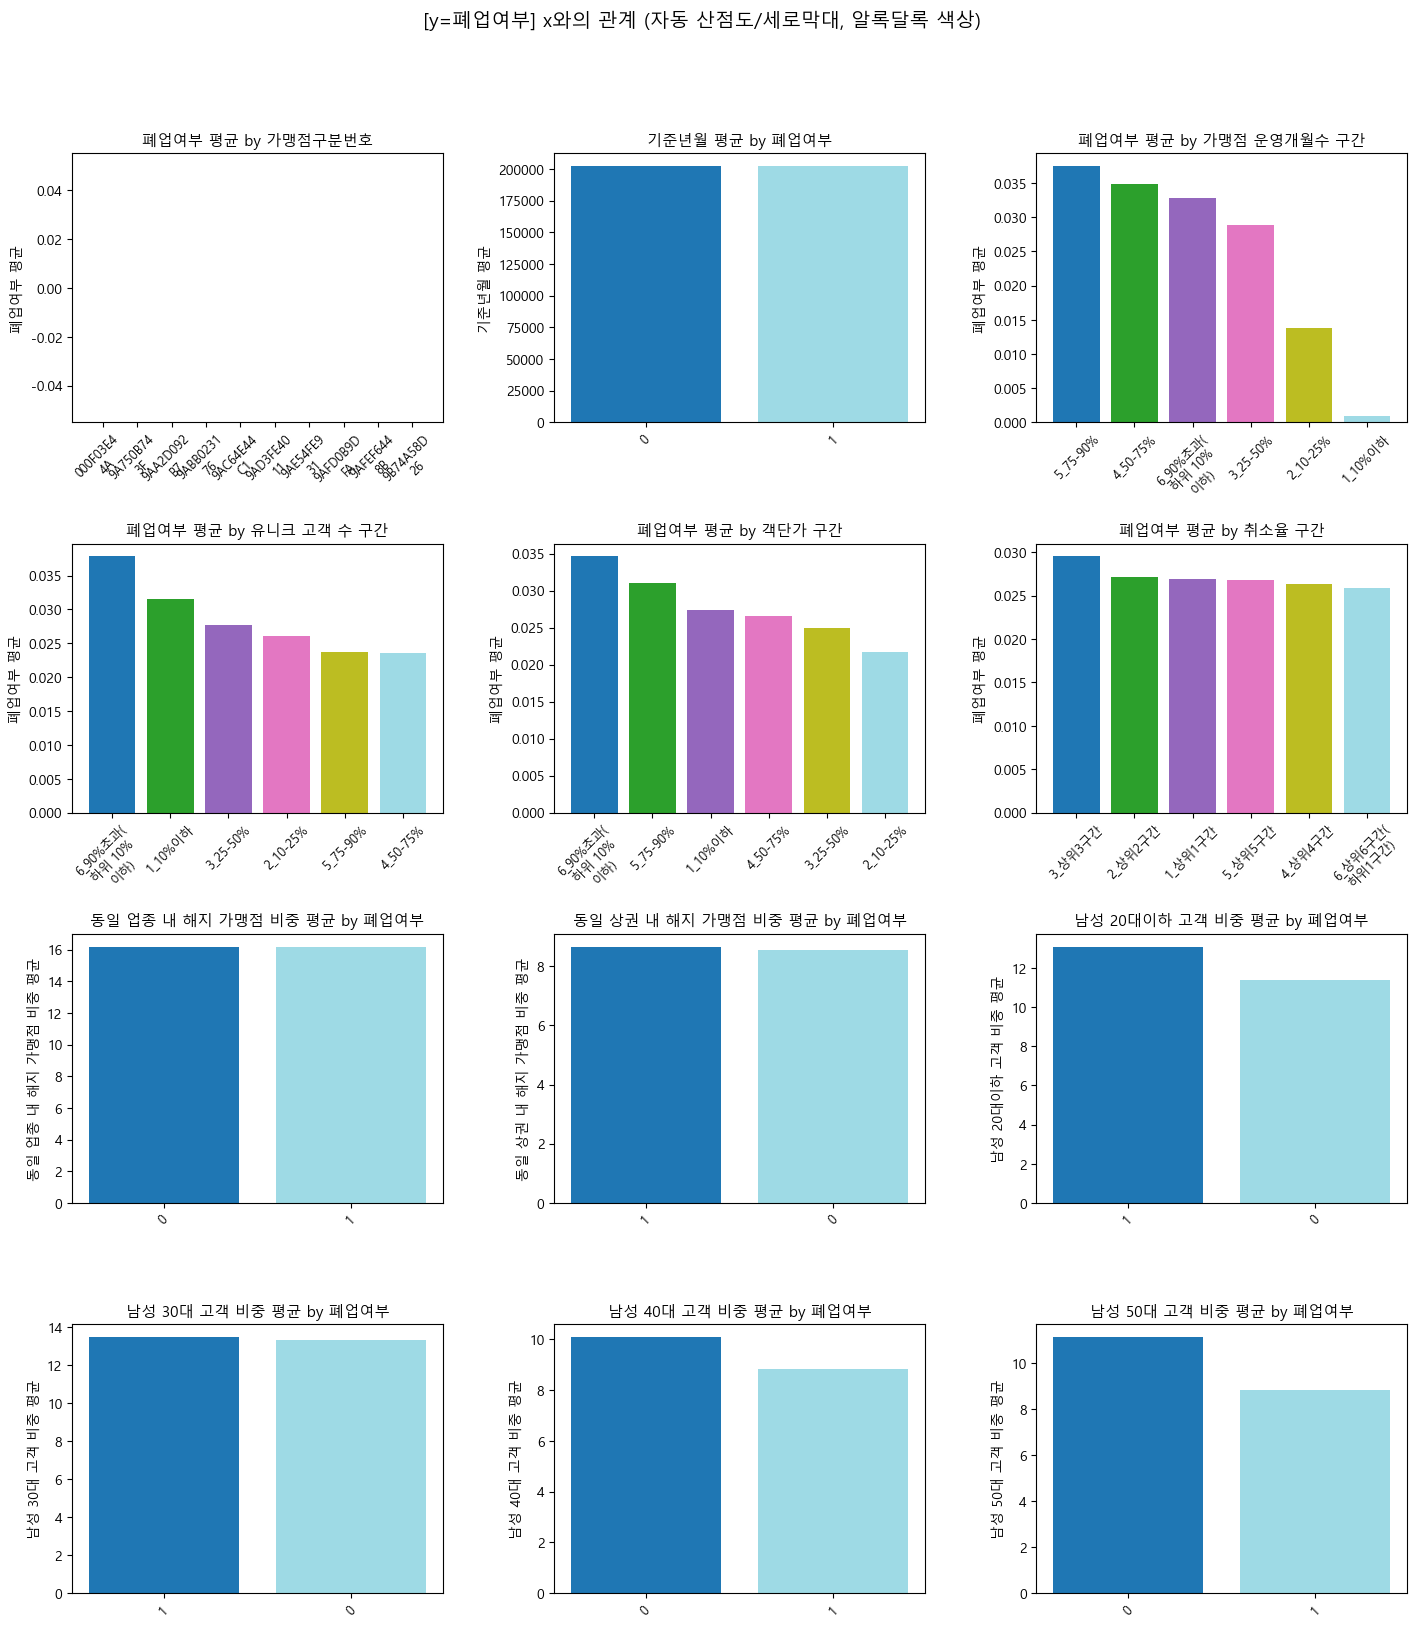

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
from matplotlib.ticker import MaxNLocator
import textwrap

# ================== 설정 ==================
MAX_X_PER_Y = 12
TOP_K_CAT = 10
FIG_NCOLS = 3
AUTO_LOG = True
X_EXCLUDE_LIKE = ["가맹점명","가맹점주소","법정동","위도","경도","개설일","폐업일"]
WRAP_CHARS = 8
FONTSIZE_TICK = 9
SCATTER_SIZE = 10
# ==========================================

def is_categorical_col(s: pd.Series) -> bool:
    if s.name and ("구간" in s.name):
        return True
    if s.dtype == "O" or s.dtype.name.startswith("string"):
        return True
    if is_numeric_dtype(s):
        return s.dropna().nunique() <= 20
    return True

def need_log_scale(s: pd.Series) -> bool:
    if not AUTO_LOG or not is_numeric_dtype(s):
        return False
    x = pd.to_numeric(s, errors="coerce").dropna()
    if x.empty: return False
    q1, q99 = np.percentile(x, [1, 99])
    if q99 <= 0: return False
    return (q99 - q1) > 1000 and (q99 / max(q1, 1e-6) > 50)

def wrap_labels(labels, width=WRAP_CHARS):
    return ["\n".join(textwrap.wrap(str(l), width=width)) for l in labels]

# 컬러맵
tab10 = plt.get_cmap("tab10")
tab20 = plt.get_cmap("tab20")

# === y 후보: '매출' 또는 '폐업' 포함 ===
all_cols = df.columns.tolist()
y_candidates = [c for c in all_cols if ("매출" in str(c)) or ("폐업" in str(c))]
print(f"[y 후보] {y_candidates}")

# === x 후보 ===
x_pool = [c for c in all_cols if c not in y_candidates and not any(k in c for k in X_EXCLUDE_LIKE)]
print(f"[x 후보 수] {len(x_pool)}")

# === y별 시각화 ===
for y in y_candidates:
    y_ser = df[y]
    usable_x = [c for c in x_pool if df[c].dropna().shape[0] > 5][:MAX_X_PER_Y]
    if not usable_x:
        print(f"[WARN] {y}: 사용할 x 없음")
        continue

    ncols = FIG_NCOLS
    nrows = int(np.ceil(len(usable_x)/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
    axes = np.ravel(axes)

    for i, xcol in enumerate(usable_x):
        ax = axes[i]
        x_ser = df[xcol]

        x_is_num = is_numeric_dtype(x_ser)
        y_is_num = is_numeric_dtype(y_ser)
        x_is_cat = is_categorical_col(x_ser)
        y_is_cat = is_categorical_col(y_ser)

        # === A. 수치-수치 ===
        if x_is_num and y_is_num and not x_is_cat and not y_is_cat:
            x_vals = pd.to_numeric(x_ser, errors="coerce")
            y_vals = pd.to_numeric(y_ser, errors="coerce")
            mask = x_vals.notna() & y_vals.notna()
            x_vals, y_vals = x_vals[mask], y_vals[mask]

            if need_log_scale(x_vals): x_vals = np.log1p(x_vals)
            if need_log_scale(y_vals): y_vals = np.log1p(y_vals)

            ax.scatter(x_vals, y_vals, s=SCATTER_SIZE, alpha=0.5, color=tab10(i % 10))
            ax.set_title(f"{y} vs {xcol}", fontsize=11)
            ax.set_xlabel("\n".join(textwrap.wrap(xcol, WRAP_CHARS)))
            ax.set_ylabel("\n".join(textwrap.wrap(y, WRAP_CHARS)))
            ax.ticklabel_format(style="plain", axis="both")
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.tick_params(axis='both', labelsize=FONTSIZE_TICK)

        # === B. 범주 x vs 수치 y ===
        elif x_is_cat and y_is_num:
            tmp = pd.DataFrame({"x": x_ser, "y": pd.to_numeric(y_ser, errors="coerce")}).dropna()
            if tmp.empty: ax.set_visible(False); continue
            top = tmp["x"].value_counts().nlargest(TOP_K_CAT).index
            g = tmp[tmp["x"].isin(top)].groupby("x")["y"].mean().sort_values(ascending=False)
            colors = [tab20(j / max(1, len(g)-1)) for j in range(len(g))]
            ax.bar(wrap_labels(g.index, WRAP_CHARS), g.values, color=colors)
            ax.set_title(f"{y} 평균 by {xcol}", fontsize=11)
            ax.tick_params(axis='x', rotation=45, labelsize=FONTSIZE_TICK)
            ax.set_ylabel(f"{y} 평균")

        # === C. 수치 x vs 범주 y ===
        elif x_is_num and y_is_cat:
            tmp = pd.DataFrame({"y": y_ser, "x": pd.to_numeric(x_ser, errors="coerce")}).dropna()
            if tmp.empty: ax.set_visible(False); continue
            top = tmp["y"].value_counts().nlargest(TOP_K_CAT).index
            g = tmp[tmp["y"].isin(top)].groupby("y")["x"].mean().sort_values(ascending=False)
            colors = [tab20(j / max(1, len(g)-1)) for j in range(len(g))]
            ax.bar(wrap_labels(g.index, WRAP_CHARS), g.values, color=colors)
            ax.set_title(f"{xcol} 평균 by {y}", fontsize=11)
            ax.tick_params(axis='x', rotation=45, labelsize=FONTSIZE_TICK)
            ax.set_ylabel(f"{xcol} 평균")

        # === D. 범주-범주: 빈도 ===
        else:
            tmp = pd.DataFrame({"x": x_ser.astype(str), "y": y_ser.astype(str)}).dropna()
            if tmp.empty: ax.set_visible(False); continue
            topx = tmp["x"].value_counts().nlargest(5).index
            topy = tmp["y"].value_counts().nlargest(5).index
            ct = (tmp[tmp["x"].isin(topx) & tmp["y"].isin(topy)]
                  .groupby(["x","y"]).size().reset_index(name="cnt"))
            ct_top = (ct.sort_values(["x","cnt"], ascending=[True, False])
                        .groupby("x", as_index=False).head(1)
                        .sort_values("cnt", ascending=False))
            colors = [tab20(j / max(1, len(ct_top)-1)) for j in range(len(ct_top))]
            ax.bar(wrap_labels(ct_top["x"].astype(str), WRAP_CHARS),
                   ct_top["cnt"].values, color=colors)
            ax.set_title(f"최다 조합 빈도: {y}~{xcol}", fontsize=11)
            ax.tick_params(axis='x', rotation=45, labelsize=FONTSIZE_TICK)
            ax.set_ylabel("빈도수")

    # 남는 축 숨김
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    # 여백 조정
    fig.subplots_adjust(hspace=0.45, wspace=0.3, left=0.08, right=0.97, bottom=0.1, top=0.9)
    plt.suptitle(f"[y={y}] x와의 관계 (자동 산점도/세로막대, 알록달록 색상)", fontsize=14)
    plt.show()


## 5. 데이터 비율(폐업일 기준)

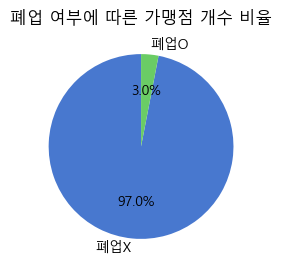

폐업일
True     4058
False     127
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

df1 = pd.read_csv("data\kor\smallbiz-data-kor-1-enriched.csv")

# 폐업일 데이터 유무에 따라 가맹점 개수 계산
closure_counts = df1['폐업일'].isnull().value_counts()

# 원그래프 그리기
plt.figure(figsize=(3, 3))
plt.pie(closure_counts, labels=['폐업X', '폐업O'], autopct='%1.1f%%', startangle=90)
plt.title('폐업 여부에 따른 가맹점 개수 비율')
plt.show()

# 결과 출력
print(closure_counts)

## 6. 외부데이터

In [2]:
import pandas as pd

df = pd.read_csv('data\smallbiz-data-preprocessed.csv')
employment = pd.read_csv('data\external\employment-indicators.csv')


C:\Users\yura1\AppData\Local\Temp\ipykernel_33564\2778387684.py:3: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\smallbiz-data-preprocessed.csv')


In [ ]:
# 삭제할 법정동 목록 (성동구가 아닌 지역 제외)
drop_동리스트 = ["논현동", "생연동"]

# 필터링 (isin 반대로 → ~)
df = df[~df["법정동"].isin(drop_동리스트)].copy()

print("삭제 완료! 현재 남은 법정동 수:", df["법정동"].nunique())
print("예시:")
print(df["법정동"].value_counts().head())


삭제 완료! 현재 남은 법정동 수: 17
예시:
법정동
성수동2가    18363
성수동1가    13112
행당동      12919
마장동       9364
용답동       4371
Name: count, dtype: int64


In [4]:
df['법정동'].unique()

array(['성수동1가', '마장동', '용답동', '성수동2가', '행당동', '도선동', '응봉동', '상왕십리동',
       '홍익동', '금호동4가', '금호동3가', '금호동1가', '송정동', '하왕십리동', '옥수동', '사근동',
       '금호동2가'], dtype=object)

In [5]:
employment.head()

,시점,경제활동참가율,경제활동참가율.1,경제활동참가율.2,실업률,실업률.1,실업률.2,고용률,고용률.1,고용률.2
0,시점,합계,남자,여자,합계,남자,여자,합계,남자,여자
1,2023. 01,61.9,69.5,55,3.4,2.9,3.9,59.8,67.5,52.9
2,2023. 02,61.9,69.6,55,2.9,2.3,3.5,60.2,68,53.1
3,2023. 03,62.6,70.3,55.5,2.8,2.4,3.3,60.8,68.6,53.7
4,2023. 04,62.5,70.6,55.2,2.8,2.3,3.3,60.8,69,53.4


In [6]:
# 1. 컬럼명을 변경하기 위한 딕셔너리 정의
new_columns = {
    '시점': '시점',  # '시점'은 그대로 유지
    '경제활동참가율': '경제활동참가율_합계',
    '경제활동참가율.1': '경제활동참가율_남자',
    '경제활동참가율.2': '경제활동참가율_여자',
    '실업률': '실업률_합계',
    '실업률.1': '실업률_남자',
    '실업률.2': '실업률_여자',
    '고용률': '고용률_합계',
    '고용률.1': '고용률_남자',
    '고용률.2': '고용률_여자'
}

# 2. 0번째 인덱스 행 제거 (실제로 데이터가 아닌 컬럼 설명 행)
# 데이터프레임 이름이 '고용지표'라고 가정합니다.
employment = employment.iloc[1:].copy()

# 3. 컬럼 이름 변경
employment.columns = new_columns.values()

# 4. 인덱스를 재설정하여 1, 2, 3...으로 깨끗하게 만듭니다.
employment = employment.reset_index(drop=True)

# 결과 확인
# print(고용지표.head())
# print(고용지표.columns)

In [7]:
import pandas as pd
import numpy as np

# 1. '시점' 컬럼을 '기준년월' 형식으로 변환

# '2023. 01' 같은 문자열에서 마침표(.)와 공백( )을 제거하고 정수형으로 변환합니다.
employment['기준년월'] = (
    employment['시점']
    .astype(str) # 혹시 모를 타입 오류 방지
    .str.replace('. ', '', regex=False)
    .astype(int)
)

# 2. 기존 '시점' 컬럼 제거
employment.drop(columns=['시점'], inplace=True)

# 3. df에 employment 데이터 병합 (Left Join)

# df의 '기준년월'과 employment의 '기준년월'을 기준으로 병합합니다.
# 'df'에 있는 모든 행은 유지되며, 일치하는 employment가 붙습니다.
# 만약 df의 '기준년월'에 해당하는 employment 데이터가 없으면 NaN이 채워집니다.
df = pd.merge(
    df,
    employment,
    on='기준년월',
    how='left'
)

# (선택) 병합 결과 확인
# print("=== df에 고용지표 병합 후 미리보기 ===")
# print(df[['가맹점구분번호', '기준년월', '경제활동참가율_합계', '실업률_합계']].head())

# (선택) NaN 값 확인: 병합된 컬럼에 NaN이 없는지 확인하여 매핑 성공 여부를 판단합니다.
# print(f"\n경제활동참가율_합계 NaN 개수: {df['경제활동참가율_합계'].isna().sum()}")

In [8]:
df.head()

,가맹점구분번호,기준년월,가맹점 운영개월수 구간,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,취소율 구간,배달매출금액 비율,동일 업종 매출금액 비율,...,405060합비율,경제활동참가율_합계,경제활동참가율_남자,경제활동참가율_여자,실업률_합계,실업률_남자,실업률_여자,고용률_합계,고용률_남자,고용률_여자
0,000F03E44A,202301,5_75-90%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,4_50-75%,1_상위1구간,0.0,0.5,...,1.000,61.9,69.5,55,3.4,2.9,3.9,59.8,67.5,52.9
1,000F03E44A,202302,5_75-90%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),1_상위1구간,0.0,0.0,...,1.000,61.9,69.6,55,2.9,2.3,3.5,60.2,68,53.1
2,000F03E44A,202303,5_75-90%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),1_상위1구간,0.0,0.0,...,1.000,62.6,70.3,55.5,2.8,2.4,3.3,60.8,68.6,53.7
3,000F03E44A,202304,5_75-90%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,3_25-50%,1_상위1구간,0.0,1.3,...,0.500,62.5,70.6,55.2,2.8,2.3,3.3,60.8,69,53.4
4,000F03E44A,202305,5_75-90%,6_90%초과(하위 10% 이하),5_75-90%,5_75-90%,6_90%초과(하위 10% 이하),1_상위1구간,0.0,0.0,...,0.333,63.3,71.4,56.1,2.7,2.8,2.6,61.6,69.4,54.7


In [9]:
df.columns

Index(['가맹점구분번호', '기준년월', '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간',
       '객단가 구간', '취소율 구간', '배달매출금액 비율', '동일 업종 매출금액 비율', '동일 업종 매출건수 비율',
       '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중',
       '동일 상권 내 해지 가맹점 비중', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중',
       '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중',
       '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중', '재방문 고객 비중',
       '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율', '가맹점주소',
       '가맹점명', '브랜드구분코드', '가맹점지역', '업종', '상권', '개설일', '폐업일', '경도', '위도', '법정동',
       '폐업여부', '20대이하', '30대', '40대', '50대', '60대이상', '남성합계비율', '여성합계비율',
       '2030합비율', '405060합비율', '경제활동참가율_합계', '경제활동참가율_남자', '경제활동참가율_여자',
       '실업률_합계', '실업률_남자', '실업률_여자', '고용률_합계', '고용률_남자', '고용률_여자'],
      dtype='object')

In [10]:
df.to_csv("data\smallbiz-data-final.csv", index=False, encoding="utf-8-sig")

### 외부데이터와 폐업률과의 관계

C:\Users\yura1\AppData\Local\Temp\ipykernel_24936\3527851460.py:7: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data\smallbiz-data-final.csv")


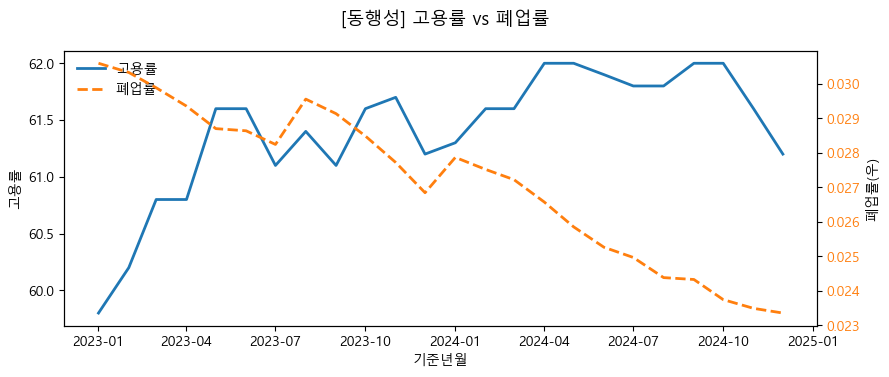

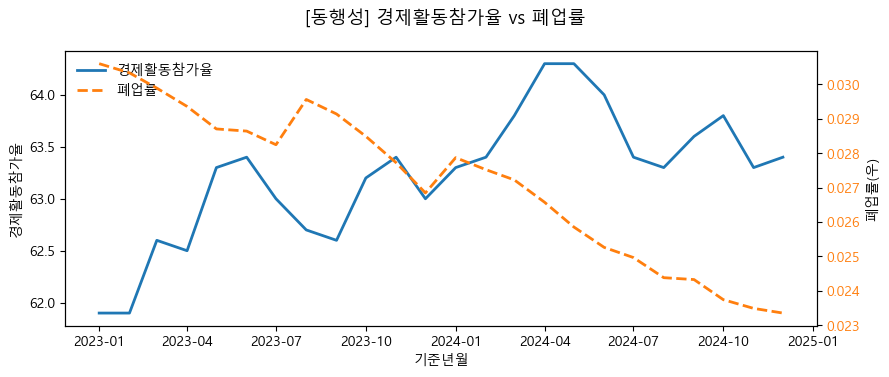

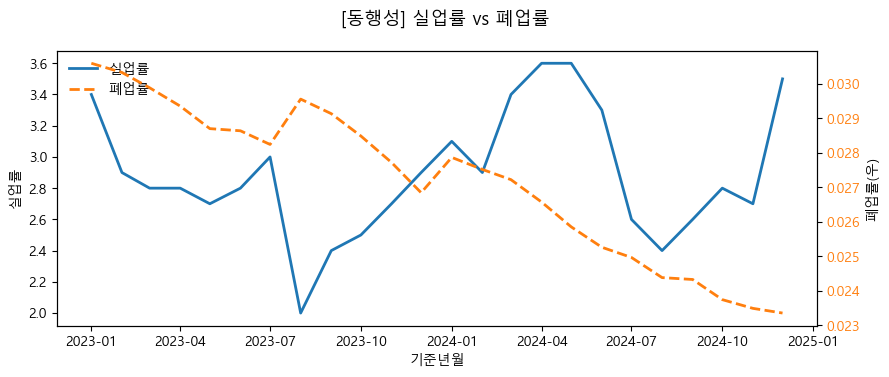

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# === 1) smallbiz-data-final.csv 불러오기 ===
df = pd.read_csv("data\smallbiz-data-final.csv")

# === 2) monthly 준비 (자동 생성) ===
if "__dt__" not in df.columns:
    if "기준년월" in df.columns:
        df["__dt__"] = pd.to_datetime(df["기준년월"].astype(str), format="%Y%m", errors="coerce")
    else:
        date_cols = [c for c in df.columns if re.search(r"(date|일자|기준일|ym|기준년월)", c, flags=re.I)]
        cand = date_cols[0]
        df["__dt__"] = pd.to_datetime(df[cand], errors="coerce")

alias = {
    "고용률": ["고용률_합계", "고용률"],
    "실업률": ["실업률_합계", "실업률"],
    "경제활동참가율": ["경제활동참가율_합계", "경제활동참가율"],
}
macro_cols = {}
for k, cands in alias.items():
    for c in cands:
        if c in df.columns:
            macro_cols[k] = c
            break

for c in macro_cols.values():
    if df[c].dtype == "object":
        df[c] = pd.to_numeric(df[c].astype(str).str.replace("%","", regex=False), errors="coerce")

agg_dict = {v: "mean" for v in macro_cols.values()}
macro_month = df.groupby("__dt__", as_index=False).agg(agg_dict).rename(columns={v:k for k,v in macro_cols.items()})

if "폐업여부" in df.columns:
    close_by_month = df.groupby("__dt__")["폐업여부"].mean().reset_index(name="폐업률")
else:
    close_by_month = pd.DataFrame({"__dt__": macro_month["__dt__"], "폐업률": np.nan})

monthly = macro_month.merge(close_by_month, on="__dt__", how="outer").sort_values("__dt__")
monthly = monthly.rename(columns={"__dt__":"기준년월"})

# === 3) 동행성 그래프 ===
metrics = ["고용률", "경제활동참가율", "실업률"]

for m in metrics:
    if m not in monthly.columns:
        print(f"[스킵] {m} 없음")
        continue
    if monthly[m].notna().sum() < 3 or monthly["폐업률"].notna().sum() < 3:
        print(f"[경고] {m}: 유효 표본 부족")
        continue

    fig, ax1 = plt.subplots(figsize=(9, 3.8))
    l1, = ax1.plot(monthly["기준년월"], monthly[m], linewidth=2, label=m)
    ax1.set_xlabel("기준년월"); ax1.set_ylabel(m)
    ax1.tick_params(axis="y")

    ax2 = ax1.twinx()
    l2, = ax2.plot(monthly["기준년월"], monthly["폐업률"],
                   linestyle="--", linewidth=2, label="폐업률", color="tab:orange")
    ax2.set_ylabel("폐업률(우)"); ax2.tick_params(axis="y", labelcolor="tab:orange")

    ax1.legend([l1, l2], [m, "폐업률"], loc="upper left", frameon=False)
    fig.suptitle(f"[동행성] {m} vs 폐업률", fontsize=13)
    plt.tight_layout(); plt.show()


고용률과 경제활동참가율이 상승할수록 폐업률이 유의하게 낮아지는 경향을 확인함.
-> 고용 및 경기 여건이 개선될수록 소상공인의 경영 안정성이 높아진다는 점을 보여주며, 외부 거시지표를 모델에 포함하는 것이 타당함.

### 외부데이터 시각화

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ========= 0) 설정 =========
# KPI(경기 민감도를 볼 지표) 바꿔도 됨: '동일 업종 매출금액 비율', '재방문 고객 비중', '배달매출금액 비율' 등
KPI_CANDIDATES = ['동일 업종 매출금액 비율','재방문 고객 비중','배달매출금액 비율']
COHORT_COLS = ['남성합계비율','여성합계비율','20대이하','30대','40대','50대','60대이상']

# ========= 1) 전처리 =========
df = df.copy()
# % 제거 → 숫자
for c in ['실업률_합계','고용률_합계','실업률_남자','실업률_여자','고용률_남자','고용률_여자']:
    if c in df.columns and df[c].dtype == 'object':
        df[c] = pd.to_numeric(df[c].astype(str).replace('%','', regex=True), errors='coerce')
# 기준년월 날짜화
df['기준년월_dt'] = pd.to_datetime(df['기준년월'].astype(str)+'01', format='%Y%m%d', errors='coerce')

# KPI 선택 (첫 번째 존재하는 것)
KPI = next((c for c in KPI_CANDIDATES if c in df.columns), None)
if KPI is None:
    raise ValueError("KPI 컬럼이 없음. 후보 중 하나가 df에 있어야 합니다: " + ", ".join(KPI_CANDIDATES))

# 월×업종 평균(노이즈 제거)
use_cols = ['업종','기준년월_dt', KPI, '실업률_합계','고용률_합계'] + [c for c in COHORT_COLS if c in df.columns]
monthly = (df[use_cols]
           .groupby(['기준년월_dt','업종'], as_index=False)
           .mean(numeric_only=True))

# 경기지수(높을수록 나쁨) – 실업률(z) - 고용률(z)
monthly['실업률_z'] = (monthly['실업률_합계']-monthly['실업률_합계'].mean())/monthly['실업률_합계'].std(ddof=0)
monthly['고용률_z'] = (monthly['고용률_합계']-monthly['고용률_합계'].mean())/monthly['고용률_합계'].std(ddof=0)
monthly['경기지수']  = monthly['실업률_z'] - monthly['고용률_z']  # ↑일수록 경기 나쁨

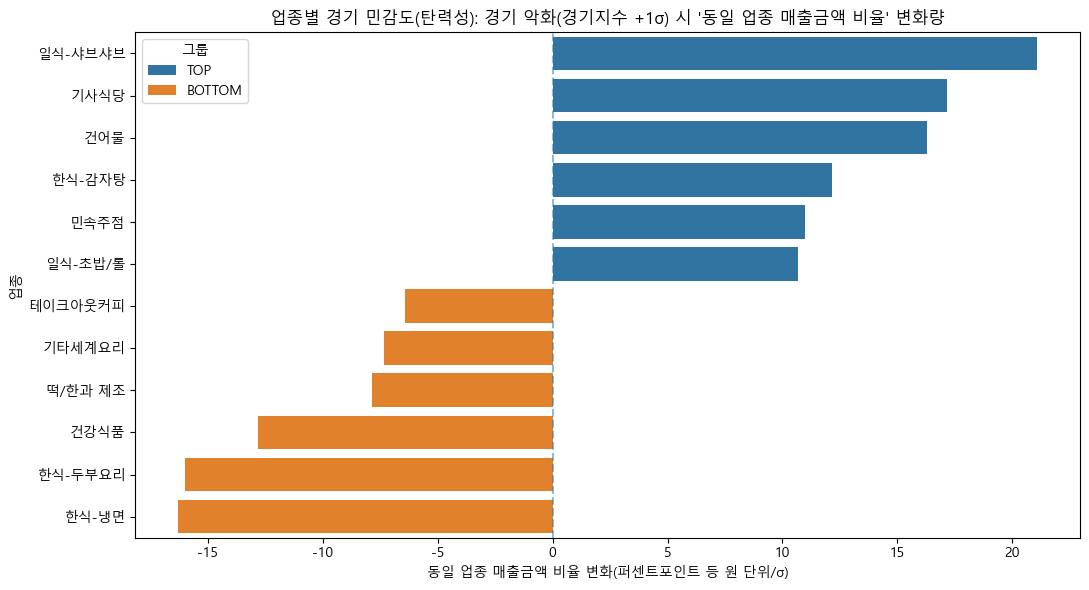

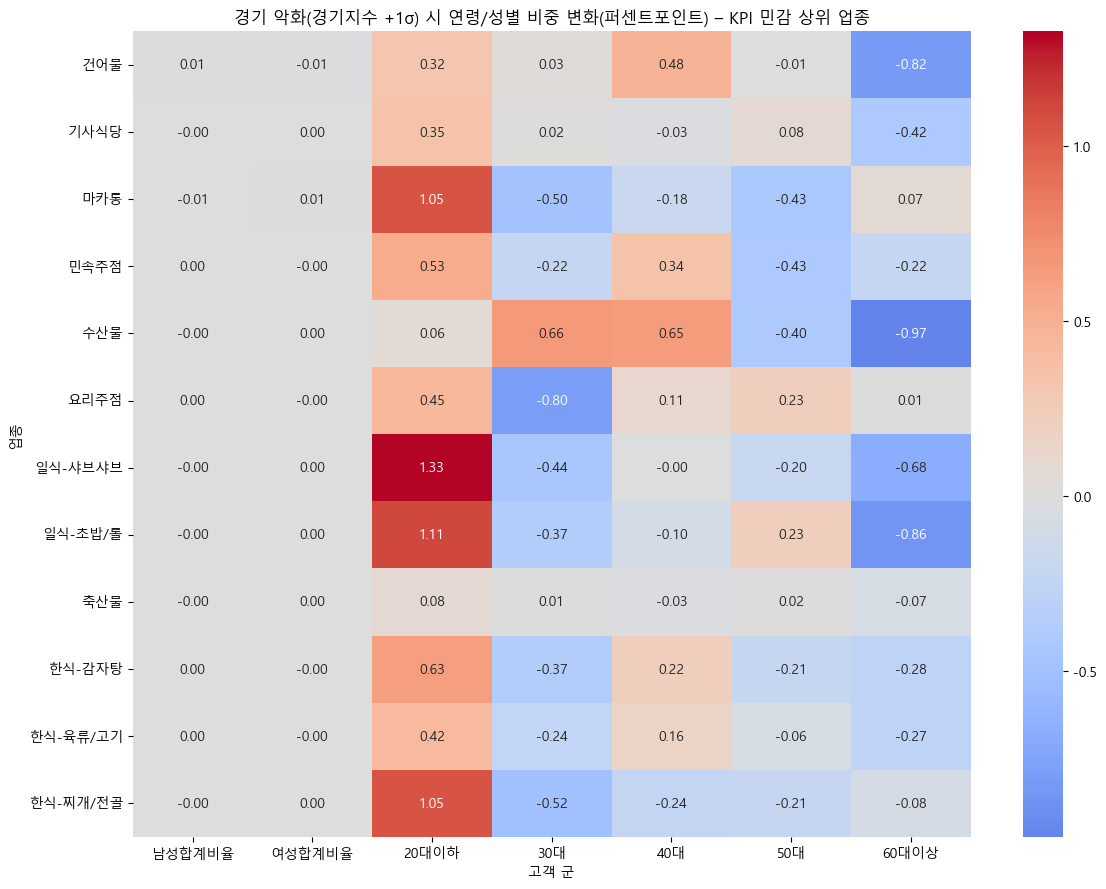

업종별 요약(상위 15행):


,업종,KPI_탄력성,피어슨r,p_value,n_months,남성합계비율,여성합계비율,20대이하,30대,40대,50대,60대이상,버팀목_고객군,역풍_고객군
0,일식-샤브샤브,21.081074,0.323906,0.122572,24,-0.002200,0.002200,1.326861,-0.443991,-0.003948,-0.200334,-0.676254,20대이하(1.33),60대이상(-0.68)
1,기사식당,17.177587,0.202049,0.343737,24,-0.003876,0.003876,0.349588,0.016528,-0.029435,0.077616,-0.419910,20대이하(0.35),60대이상(-0.42)
2,건어물,16.290199,0.337696,0.106555,24,0.012958,-0.012958,0.318369,0.028788,0.476059,-0.006358,-0.817388,40대(0.48),60대이상(-0.82)
3,한식-감자탕,12.155689,0.392452,0.057843,24,0.003208,-0.003208,0.625533,-0.367958,0.222039,-0.210327,-0.276981,20대이하(0.63),30대(-0.37)
4,민속주점,10.972315,0.300391,0.153800,24,0.003357,-0.003357,0.530650,-0.221341,0.340146,-0.425203,-0.223877,20대이하(0.53),50대(-0.43)
5,일식-초밥/롤,10.679482,0.330294,0.114948,24,-0.000263,0.000263,1.105493,-0.371457,-0.098416,0.225400,-0.860478,20대이하(1.11),60대이상(-0.86)
6,축산물,10.612628,0.375750,0.070375,24,-0.001273,0.001273,0.078990,0.008881,-0.030727,0.015794,-0.073028,20대이하(0.08),60대이상(-0.07)
7,수산물,10.451098,0.567897,0.003794,24,-0.003292,0.003292,0.058186,0.660266,0.651966,-0.401742,-0.974936,30대(0.66),60대이상(-0.97)
8,한식-찌개/전골,8.983296,0.471295,0.020085,24,-0.000648,0.000648,1.048449,-0.515481,-0.236673,-0.210128,-0.084684,20대이하(1.05),30대(-0.52)
9,한식-육류/고기,8.425400,0.493671,0.014221,24,0.000897,-0.000897,0.417682,-0.241763,0.159737,-0.064556,-0.270750,20대이하(0.42),60대이상(-0.27)


In [29]:
# ========= 2) 업종별 KPI 탄력성(= 경기지수 1σ 변화 시 KPI 변화량) =========
rows = []
for k, g in monthly.groupby('업종'):
    g = g.dropna(subset=['경기지수', KPI])
    if len(g) < 6 or g[KPI].std(ddof=0) == 0:  # 표본/분산 체크
        continue
    x = (g['경기지수'] - g['경기지수'].mean())/g['경기지수'].std(ddof=0)   # 표준화된 경기지수(1σ)
    y = g[KPI]
    # 기울기: 경기지수 1σ ↑ 시 KPI 변화량 (단위: KPI의 원 단위, 보통 %p)
    slope = np.polyfit(x, y, 1)[0]
    r, p = pearsonr(g['경기지수'], y)
    rows.append({'업종': k, 'KPI_탄력성': slope, '피어슨r': r, 'p_value': p, 'n_months': len(g)})

sens = pd.DataFrame(rows).sort_values('KPI_탄력성', ascending=False)
top_inds = sens.head(12)['업종'].tolist()  # TOP12만 시각화

# ========= 3) 연령/성별 기여도(경기지수 1σ ↑ 시 각 비중 변화량) =========
cohort_cols = [c for c in COHORT_COLS if c in monthly.columns]
cohort_rows = []
for k, g in monthly.groupby('업종'):
    g = g.dropna(subset=['경기지수'] + cohort_cols)
    if len(g) < 6:
        continue
    x = (g['경기지수'] - g['경기지수'].mean())/g['경기지수'].std(ddof=0)
    entry = {'업종': k}
    for col in cohort_cols:
        if g[col].std(ddof=0) == 0:
            entry[col] = np.nan
        else:
            entry[col] = np.polyfit(x, g[col], 1)[0]   # 1σ 당 %p 변화량
    cohort_rows.append(entry)

cohort_beta = pd.DataFrame(cohort_rows).set_index('업종')
# KPI 민감 상위 업종만 추림
cohort_top = cohort_beta.loc[cohort_beta.index.intersection(top_inds)].copy().sort_index()

# ========= 4) 시각화 =========
# (A) 업종별 KPI 탄력성 TOP & BOTTOM
plt.figure(figsize=(11,6))
plot_sens = pd.concat([sens.head(6), sens.tail(6)]).copy()
plot_sens['그룹'] = ['TOP']*6 + ['BOTTOM']*6
sns.barplot(data=plot_sens, x='KPI_탄력성', y='업종', hue='그룹')
plt.axvline(0, ls='--', alpha=0.5)
plt.title(f"업종별 경기 민감도(탄력성): 경기 악화(경기지수 +1σ) 시 '{KPI}' 변화량")
plt.xlabel(f"{KPI} 변화(퍼센트포인트 등 원 단위/σ)")
plt.ylabel("업종"); plt.tight_layout(); plt.show()

# (B) TOP 업종들의 연령/성별 기여 히트맵
if not cohort_top.empty:
    plt.figure(figsize=(12, 0.5*len(cohort_top)+3))
    sns.heatmap(cohort_top[cohort_cols], annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title("경기 악화(경기지수 +1σ) 시 연령/성별 비중 변화(퍼센트포인트) – KPI 민감 상위 업종")
    plt.xlabel("고객 군"); plt.ylabel("업종")
    plt.tight_layout(); plt.show()

# ========= 5) 업종별 요약 테이블 (버팀목/역풍 고객군) =========
summary = sens[['업종','KPI_탄력성','피어슨r','p_value','n_months']].merge(
    cohort_beta.reset_index(), on='업종', how='left'
)

def pick_helpers(row):
    vals = row[cohort_cols].dropna()
    if vals.empty:
        return pd.Series({'버팀목_고객군': np.nan, '역풍_고객군': np.nan})
    pos = vals.sort_values(ascending=False)
    neg = vals.sort_values(ascending=True)
    return pd.Series({'버팀목_고객군': f"{pos.index[0]}({pos.iloc[0]:.2f})",
                      '역풍_고객군': f"{neg.index[0]}({neg.iloc[0]:.2f})"})

helpers = summary.apply(pick_helpers, axis=1)
summary = pd.concat([summary, helpers], axis=1).sort_values('KPI_탄력성', ascending=False)

print("업종별 요약(상위 15행):")
display(summary.head(15))


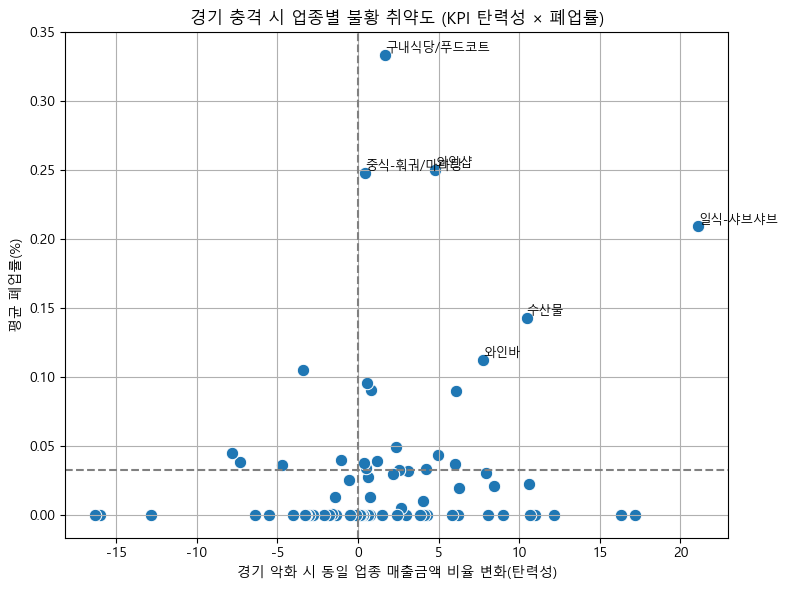

In [30]:
# 경기 민감도(sens)와 월별 폐업률 결합
close_rate = df.groupby(['기준년월_dt','업종'])['폐업여부'].mean().reset_index(name='폐업률')
close_avg = close_rate.groupby('업종')['폐업률'].mean().reset_index()

risk_map = sens.merge(close_avg, on='업종', how='inner')

plt.figure(figsize=(8,6))
sns.scatterplot(data=risk_map, x='KPI_탄력성', y='폐업률', s=80)
plt.axvline(0, ls='--', color='gray'); plt.axhline(risk_map['폐업률'].mean(), ls='--', color='gray')
for _,r in risk_map.nlargest(6, '폐업률').iterrows():
    plt.text(r.KPI_탄력성, r.폐업률, r.업종, fontsize=9, ha='left', va='bottom')
plt.title("경기 충격 시 업종별 불황 취약도 (KPI 탄력성 × 폐업률)")
plt.xlabel(f"경기 악화 시 {KPI} 변화(탄력성)")
plt.ylabel("평균 폐업률(%)")
plt.grid(True); plt.tight_layout(); plt.show()


C:\Users\yura1\AppData\Local\Temp\ipykernel_24936\935904533.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.concat([top_resilient, bottom_resilient]),


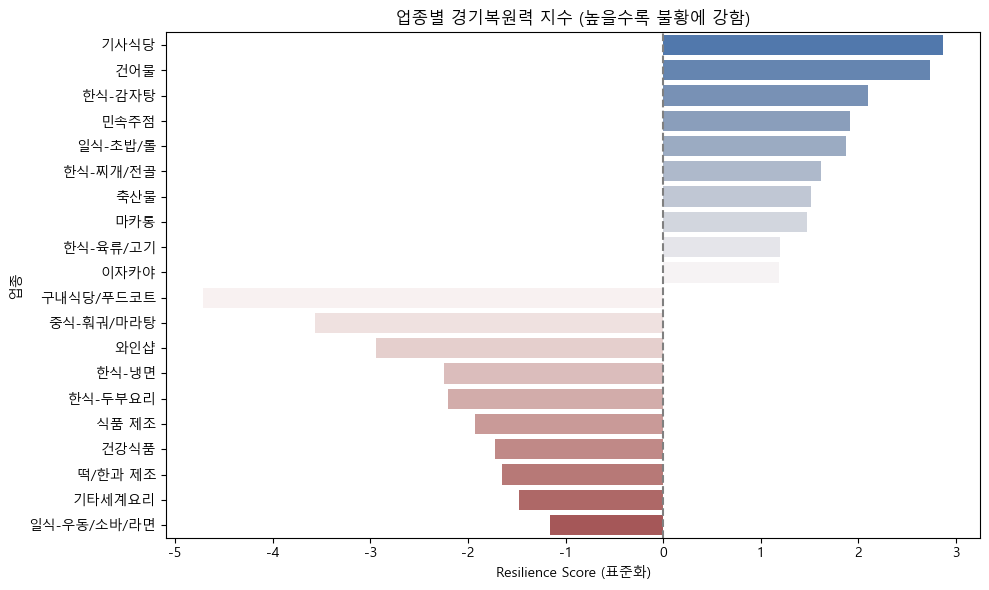

In [31]:
# 경기복원력 = KPI_탄력성의 표준화 - 폐업률 표준화
risk_map['Resilience_Score'] = (
    (risk_map['KPI_탄력성'] - risk_map['KPI_탄력성'].mean())/risk_map['KPI_탄력성'].std()
    - (risk_map['폐업률'] - risk_map['폐업률'].mean())/risk_map['폐업률'].std()
)

top_resilient = risk_map.sort_values('Resilience_Score', ascending=False).head(10)
bottom_resilient = risk_map.sort_values('Resilience_Score', ascending=True).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=pd.concat([top_resilient, bottom_resilient]),
            x='Resilience_Score', y='업종', palette='vlag')
plt.axvline(0, ls='--', color='gray')
plt.title("업종별 경기복원력 지수 (높을수록 불황에 강함)")
plt.xlabel("Resilience Score (표준화)")
plt.ylabel("업종")
plt.tight_layout(); plt.show()
